[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/08_numerical_linear_algebra_iterative_solvers/first_principles.ipynb)

# Module 08 — Numerical Linear Algebra and Iterative Solvers

## 1. Why This Module Exists

Every module before this one solves $Ax = b$ by factoring $A$. Gaussian elimination costs
$\tfrac{2}{3}n^3$ flops and destroys sparsity: the $LU$ factors of a sparse matrix are usually
dense.

At $n = 10^6$ — one modest three-dimensional grid, one medium graph, one Hessian in a
deep network — $\tfrac{2}{3}n^3$ is $6.7 \times 10^{17}$ flops and $n^2$ words of storage is
eight terabytes. Factorization is not slow here; it is impossible.

The alternative is to give up on the exact answer and build a sequence $x_0, x_1, x_2, \dots$
whose only interaction with $A$ is the product $A v$. That product costs
$2\operatorname{nnz}(A)$ flops and needs no extra memory.

Two questions then decide everything. Does the sequence converge, and how fast? This module
answers both: for a stationary method the answer is the spectral radius of one matrix, and for
the conjugate gradient method it is $\sqrt{\kappa_2(A)}$ — a square root that turns a hopeless
iteration count into a practical one.

## 2. Intuition

Think of an iterative solver as a filter applied to the error.

Every method in this module produces an iterate of the form $x_k = x_0 + q_{k-1}(A) r_0$ for
some polynomial $q_{k-1}$ of degree at most $k-1$. The error obeys

$$
e_k = p_k(A) \, e_0, \qquad p_k(t) = 1 - t \, q_{k-1}(t), \quad p_k(0) = 1 .
$$

So an iterative method is a machine for choosing polynomials that are $1$ at the origin and as
small as possible on the spectrum of $A$.

A stationary method commits in advance to one fixed polynomial family and therefore to one
contraction factor per step. The conjugate gradient method instead picks, at every $k$, the
*best possible* polynomial for the actual error it is holding.

That is the whole difference. The picture below runs Jacobi, Gauss-Seidel, optimally relaxed
SOR and CG on the same system — the one-dimensional discrete Laplacian — and lets the four
error histories speak.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, and prints the two floating-point constants that every
later residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps       # gap at 1, = 2^-52
U = EPS / 2                     # unit roundoff, = 2^-53
print(f"eps_mach = {EPS:.6e}   = 2^{np.log2(EPS):.0f}")
print(f"u        = {U:.6e}   = 2^{np.log2(U):.0f}")

eps_mach = 2.220446e-16   = 2^-52
u        = 1.110223e-16   = 2^-53


Every residual reported later is quoted as a multiple of $\varepsilon_{\mathrm{mach}}$.

The next cell builds the $16 \times 16$ one-dimensional discrete Laplacian
$A = \operatorname{tridiag}(-1, 2, -1)$, generates a right-hand side from a known solution, and
runs four solvers from $x_0 = 0$: Jacobi, Gauss-Seidel, SOR at its optimal relaxation parameter,
and the conjugate gradient method. It plots the relative error $\lVert x_k - x \rVert_2 / \lVert x \rVert_2$
against the iteration index, with the three predicted geometric decay rates as dashed lines.

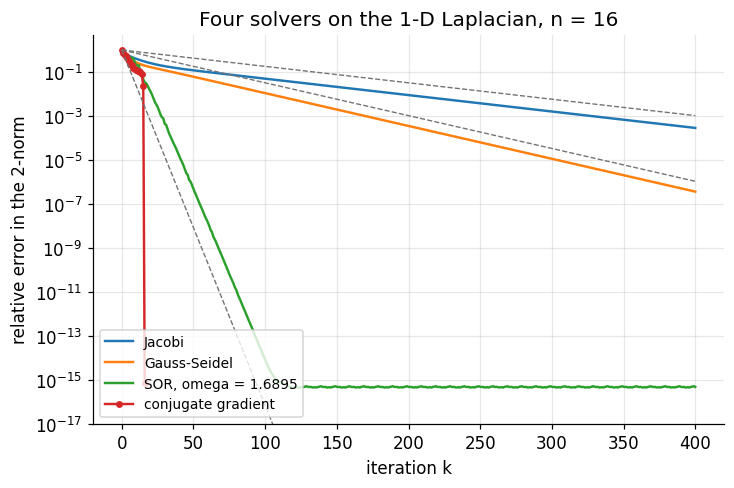

spectral radii:  Jacobi 0.982973   Gauss-Seidel 0.966236   SOR 0.689547
relative error after 400 steps:  Jacobi 2.871e-04   Gauss-Seidel 3.671e-07   SOR 4.959e-16
relative error of CG after n = 16 steps: 7.540e-16


In [2]:
def laplacian_1d(n):
    """The n-by-n matrix tridiag(-1, 2, -1), the standard 1-D Poisson operator."""
    return (np.diag(2.0 * np.ones(n))
            + np.diag(-np.ones(n - 1), 1)
            + np.diag(-np.ones(n - 1), -1))


n = 16
A = laplacian_1d(n)
D = np.diag(np.diag(A))
Lo = -np.tril(A, -1)            # A = D - Lo - Up
Up = -np.triu(A, 1)

x_star = rng.standard_normal(n)
b = A @ x_star

G_jac = np.linalg.solve(D, Lo + Up)
G_gs = np.linalg.solve(D - Lo, Up)
rho_jac = max(abs(np.linalg.eigvals(G_jac)))
rho_gs = max(abs(np.linalg.eigvals(G_gs)))
omega = 2.0 / (1.0 + np.sqrt(1.0 - rho_jac ** 2))
M_sor = D / omega - Lo
N_sor = (1.0 / omega - 1.0) * D + Up
rho_sor = max(abs(np.linalg.eigvals(np.linalg.solve(M_sor, N_sor))))


def stationary(M, N, iters):
    """Run x <- M^-1 (N x + b) and return the relative error history."""
    x = np.zeros(n)
    err = [np.linalg.norm(x - x_star)]
    for _ in range(iters):
        x = np.linalg.solve(M, N @ x + b)
        err.append(np.linalg.norm(x - x_star))
    return np.array(err) / np.linalg.norm(x_star)


def cg_errors(A, b, x_star, iters):
    """Conjugate gradient from x0 = 0; returns the relative error history."""
    x = np.zeros(len(b))
    r = b - A @ x
    p = r.copy()
    rr = r @ r
    err = [np.linalg.norm(x - x_star)]
    for _ in range(iters):
        Ap = A @ p
        alpha = rr / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rr_new = r @ r
        p = r + (rr_new / rr) * p
        rr = rr_new
        err.append(np.linalg.norm(x - x_star))
    return np.array(err) / np.linalg.norm(x_star)


steps = 400
e_jac = stationary(D, Lo + Up, steps)
e_gs = stationary(D - Lo, Up, steps)
e_sor = stationary(M_sor, N_sor, steps)
e_cg = cg_errors(A, b, x_star, n)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
k_long = np.arange(steps + 1)
ax.semilogy(k_long, np.maximum(e_jac, 1e-17), lw=1.6, label="Jacobi")
ax.semilogy(k_long, np.maximum(e_gs, 1e-17), lw=1.6, label="Gauss-Seidel")
ax.semilogy(k_long, np.maximum(e_sor, 1e-17), lw=1.6, label=f"SOR, omega = {omega:.4f}")
ax.semilogy(np.arange(n + 1), np.maximum(e_cg, 1e-17), "o-", ms=3.5, lw=1.6,
            label="conjugate gradient")
for rho, name in [(rho_jac, "Jacobi"), (rho_gs, "Gauss-Seidel"), (rho_sor, "SOR")]:
    ax.semilogy(k_long, rho ** k_long, ls="--", lw=0.9, color="0.45")
ax.set_ylim(1e-17, 5.0)
ax.set_xlabel("iteration k")
ax.set_ylabel("relative error in the 2-norm")
ax.set_title("Four solvers on the 1-D Laplacian, n = 16")
ax.legend(fontsize=9, loc="lower left")
plt.show()

print(f"spectral radii:  Jacobi {rho_jac:.6f}   Gauss-Seidel {rho_gs:.6f}   SOR {rho_sor:.6f}")
print(f"relative error after {steps} steps:  Jacobi {e_jac[-1]:.3e}   "
      f"Gauss-Seidel {e_gs[-1]:.3e}   SOR {e_sor[-1]:.3e}")
print(f"relative error of CG after n = {n} steps: {e_cg[-1]:.3e}")

The three dashed grey lines are $\rho(G)^k$ for the three stationary methods, and each solid
curve tracks its own dashed line: the contraction factor really is the spectral radius of the
iteration matrix.

Gauss-Seidel halves the number of iterations Jacobi needs, because
$\rho(G_{\mathrm{GS}}) = \rho(G_{\mathrm{J}})^2$ for this matrix. Optimal SOR does far better
still, at the cost of needing $\rho(G_{\mathrm{J}})$ in advance.

The conjugate gradient curve is different in kind. It is not a straight line, it bends downwards,
and it hits $10^{-16}$ after exactly $n = 16$ steps while Jacobi is still at $3 \times 10^{-4}$
after $400$. Sections 4 and 5 explain both features: the bend is the optimal polynomial adapting
to the spectrum, and the termination is Theorem 4.5.

## 3. Definitions

Throughout, $A \in \mathbb{R}^{n \times n}$ is non-singular, $b \in \mathbb{R}^n$, and $x$ solves
$Ax = b$. Iterates are $x_k$, errors are $e_k = x - x_k$, and residuals are
$r_k = b - Ax_k$. Symbol conventions follow
[the notation register](../../docs/notation.md): eigenvalues descending, norms written
$\lVert \cdot \rVert$, transposes written $A^{\top}$, and $T_k$ reserved for the Chebyshev
polynomial of the first kind.

### Definition 3.1 — Unit roundoff and the floating-point model

A binary floating-point system with $t$ significand bits (the hidden bit included) has
**unit roundoff** $u = 2^{-t}$ and machine epsilon $\varepsilon_{\mathrm{mach}} = 2u$, the gap
between $1$ and the next representable number. For IEEE binary64, $t = 53$, so
$u = 2^{-53}$ and $\varepsilon_{\mathrm{mach}} = 2^{-52}$.

The standard model of IEEE arithmetic is that for
$\odot \in \{ +, -, \times, / \}$ and representable $x, y$,

$$
\operatorname{fl}(x \odot y) = (x \odot y)(1 + \delta), \qquad \lvert \delta \rvert \le u .
$$

Repeated rounding accumulates into **Wilkinson's factor**

$$
\gamma_n = \frac{nu}{1 - nu},
$$

which is the constant that appears in every backward-error bound below.

### Definition 3.2 — Forward error, backward error, backward stability

Let $\hat{x}$ be the computed solution of $Ax = b$.

- The **forward error** is $\lVert \hat{x} - x \rVert / \lVert x \rVert$.
- The **backward error** is the smallest $\eta$ such that
  $(A + \Delta A)\hat{x} = b + \Delta b$ for some $\Delta A, \Delta b$ with
  $\lVert \Delta A \rVert \le \eta \lVert A \rVert$ and $\lVert \Delta b \rVert \le \eta \lVert b \rVert$.

An algorithm is **backward stable** when its backward error is $O(u)$ for every input: the
computed answer is the exact answer to a nearby question.

### Definition 3.3 — Condition number

For a non-singular $A$ and an induced matrix norm,

$$
\kappa(A) = \lVert A \rVert \, \lVert A^{-1} \rVert .
$$

In the $2$-norm this is $\kappa_2(A) = \sigma_1/\sigma_n$, and for symmetric positive definite
$A$ it is $\lambda_{\max}/\lambda_{\min}$. Note $\kappa(A) \ge 1$ always, since
$1 = \lVert I \rVert \le \lVert A \rVert \lVert A^{-1} \rVert$.

**Conditioning is a property of the problem, stability a property of the algorithm.** The two
combine as: forward error $\lesssim \kappa(A) \times$ backward error. The full treatment is
[numerical_computing/03](../../numerical_computing/03_conditioning_and_condition_numbers/);
only what is needed here is repeated.

### Definition 3.4 — Splitting, iteration matrix, stationary method

A **splitting** of $A$ is $A = M - N$ with $M$ non-singular and $Mv = c$ cheap to solve. The
associated **stationary iteration** is

$$
M x_{k+1} = N x_k + b, \qquad \text{equivalently} \qquad x_{k+1} = G x_k + M^{-1} b,
$$

with **iteration matrix** $G = M^{-1}N = I - M^{-1}A$. It is called stationary because $G$ does
not depend on $k$.

Writing $A = D - L - U$ with $D$ the diagonal, $-L$ the strictly lower and $-U$ the strictly
upper triangular part, the three classical choices are

| Method | $M$ | $N$ | Iteration matrix |
|---|---|---|---|
| Jacobi | $D$ | $L + U$ | $G_{\mathrm{J}} = D^{-1}(L+U)$ |
| Gauss-Seidel | $D - L$ | $U$ | $G_{\mathrm{GS}} = (D-L)^{-1}U$ |
| SOR, $\omega \in (0,2)$ | $\omega^{-1}D - L$ | $(\omega^{-1} - 1)D + U$ | $G_\omega = (\omega^{-1}D - L)^{-1}\bigl((\omega^{-1}-1)D + U\bigr)$ |

SOR at $\omega = 1$ is Gauss-Seidel.

### Definition 3.5 — Spectral radius and asymptotic rate

The **spectral radius** of $G$ is $\rho(G) = \max \{ \lvert \lambda \rvert : \lambda \in \operatorname{spec}(G) \}$,
as in [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).

When $\rho(G) \lt 1$ the **asymptotic convergence rate** is

$$
R_\infty(G) = -\ln \rho(G),
$$

so reducing the error by $10^{-d}$ takes about $d \ln(10) / R_\infty(G)$ iterations.

### Definition 3.6 — Krylov subspace

For $A \in \mathbb{R}^{n \times n}$ and $v \neq 0$, the $k$-th **Krylov subspace** is

$$
\mathcal{K}_k(A, v) = \operatorname{span}\{ v, Av, A^2 v, \dots, A^{k-1}v \} .
$$

Equivalently $\mathcal{K}_k(A,v) = \{ q(A) v : \deg q \le k-1 \}$: it is exactly the set of
vectors a $k$-term polynomial in $A$ can reach from $v$, which is why polynomials govern
everything in Sections 4 and 5.

### Definition 3.7 — The $A$-inner product, the energy norm, conjugacy

Let $A$ be symmetric positive definite. Then

$$
\langle u, v \rangle_A = u^{\top} A v, \qquad \lVert v \rVert_A = \sqrt{v^{\top} A v}
$$

define an inner product and its norm, called the **energy norm**. Positive definiteness is what
makes $\lVert v \rVert_A = 0$ force $v = 0$.

Vectors $p_i, p_j$ are **$A$-conjugate** when $p_i^{\top} A p_j = 0$ for $i \neq j$: orthogonal
in the $A$-inner product.

### Definition 3.8 — The conjugate gradient algorithm

Let $A$ be symmetric positive definite. Given $x_0$, set $r_0 = b - Ax_0$ and $p_0 = r_0$. For
$k = 0, 1, 2, \dots$, while $r_k \neq 0$:

$$
\alpha_k = \frac{r_k^{\top} r_k}{p_k^{\top} A p_k}, \qquad
x_{k+1} = x_k + \alpha_k p_k, \qquad
r_{k+1} = r_k - \alpha_k A p_k,
$$

$$
\beta_k = \frac{r_{k+1}^{\top} r_{k+1}}{r_k^{\top} r_k}, \qquad
p_{k+1} = r_{k+1} + \beta_k p_k .
$$

One iteration costs one product $Ap_k$, two inner products and three vector updates. Nothing
older than step $k$ is stored — three vectors in total, whatever $n$ is.

### Definition 3.9 — Arnoldi iteration and GMRES

The **Arnoldi iteration** applies Gram-Schmidt to the Krylov sequence. Starting from
$q_1 = r_0 / \lVert r_0 \rVert_2$, for $j = 1, 2, \dots$:

$$
h_{ij} = q_i^{\top} A q_j \ (i \le j), \qquad
v_j = Aq_j - \sum_{i=1}^{j} h_{ij} q_i, \qquad
h_{j+1,j} = \lVert v_j \rVert_2, \qquad q_{j+1} = v_j / h_{j+1,j} .
$$

It produces $Q_k$ with orthonormal columns spanning $\mathcal{K}_k(A, r_0)$ and an
$(k+1) \times k$ upper Hessenberg $\bar{H}_k$.

**GMRES** then takes $x_k = x_0 + Q_k y_k$ with $y_k$ minimizing $\lVert b - Ax \rVert_2$ over
$x_0 + \mathcal{K}_k(A, r_0)$.

### Definition 3.10 — Preconditioner

A **preconditioner** is a non-singular $M$ for which $Mv = c$ is cheap and $M^{-1}A$ has a
better spectrum than $A$. The preconditioned system is $M^{-1}Ax = M^{-1}b$ (left), $AM^{-1}y = b$
with $x = M^{-1}y$ (right), or, for symmetric positive definite $A$ and $M = LL^{\top}$,

$$
(L^{-1}AL^{-\top}) (L^{\top}x) = L^{-1}b \qquad \text{(split)},
$$

which keeps the matrix symmetric positive definite so that CG still applies.

## 4. Main Results

Theorem 4.1 measures how much the answer can move when the data moves; it is the reason a
correct algorithm can still return a bad answer. Theorems 4.2 to 4.5 settle stationary methods:
one exact convergence criterion and two sufficient conditions that are checkable from the entries
of $A$.

Theorems 4.6 and 4.7 are the results the module is named after. They state what the conjugate
gradient method computes and how fast, and they are proved in full in Section 5. Theorem 4.8
does the same for non-symmetric matrices, Theorem 4.9 states what preconditioning buys, and
Theorem 4.10 is quoted rather than proved.

### Theorem 4.1 — Error amplification is exactly the condition number

Let $A$ be non-singular, $b \neq 0$, $Ax = b$ and $A(x + \Delta x) = b + \Delta b$. Then

$$
\frac{\lVert \Delta x \rVert}{\lVert x \rVert} \;\le\; \kappa(A) \, \frac{\lVert \Delta b \rVert}{\lVert b \rVert},
$$

and in the $2$-norm the bound is **attained**: for every $A$ there are $b$ and $\Delta b$ making
it an equality.

If in addition $A$ is perturbed, $(A + \Delta A)(x + \Delta x) = b + \Delta b$, and
$\lVert A^{-1} \rVert \lVert \Delta A \rVert \lt 1$, then

$$
\frac{\lVert \Delta x \rVert}{\lVert x \rVert} \;\le\;
\frac{\kappa(A)}{1 - \kappa(A) \frac{\lVert \Delta A \rVert}{\lVert A \rVert}}
\left( \frac{\lVert \Delta b \rVert}{\lVert b \rVert} + \frac{\lVert \Delta A \rVert}{\lVert A \rVert} \right).
$$

**Hypotheses.** Non-singularity of $A$ is needed for $x$ to exist and for $\kappa(A)$ to be
finite. The extra assumption $\lVert A^{-1} \rVert \lVert \Delta A \rVert \lt 1$ is what keeps
$A + \Delta A$ non-singular; without it the perturbed system may have no solution at all, and
Problem L3.1 of [`exercises.ipynb`](exercises.ipynb) shows the threshold is sharp.

**Interpretation.** A backward stable solver returns $\hat{x}$ with backward error $O(u)$, so its
forward error is bounded by roughly $\kappa(A) u$ and no better. A large error is then the
problem's fault, not the algorithm's.

Proved as Proof 5.1.

### Theorem 4.2 — Convergence of a stationary iteration

Let $A = M - N$ with $M$ non-singular and $G = M^{-1}N$. The iteration
$x_{k+1} = Gx_k + M^{-1}b$ converges to $x = A^{-1}b$ for **every** starting vector $x_0$ if and
only if

$$
\rho(G) \lt 1 .
$$

Moreover $\lVert G^k \rVert^{1/k} \to \rho(G)$ for every induced norm, so $\rho(G)$ is also the
asymptotic per-step contraction factor and not merely a threshold.

**Hypotheses.** $M$ must be non-singular for the iteration to be defined. Nothing is assumed
about $A$ beyond $A = M - N$; in particular $A$ need not be symmetric.

**Interpretation.** The criterion is asymptotic, not monotone. When $G$ is non-normal,
$\lVert G^k \rVert$ can grow by orders of magnitude before it decays — Example 6.5 exhibits a
$2 \times 2$ matrix with $\rho(G) = 0.9$ whose powers first grow nineteen-fold.

Proved as Proof 5.2.

### Theorem 4.3 — Strict diagonal dominance suffices for Jacobi and Gauss-Seidel

Let $A$ satisfy $\lvert a_{ii} \rvert \gt \sum_{j \neq i} \lvert a_{ij} \rvert$ for every $i$
(strict row diagonal dominance). Then $a_{ii} \neq 0$, both iteration matrices are defined, and

$$
\rho(G_{\mathrm{GS}}) \;\le\; \lVert G_{\mathrm{GS}} \rVert_\infty \;\le\; \lVert G_{\mathrm{J}} \rVert_\infty \;\lt\; 1 .
$$

Both methods therefore converge from every $x_0$.

**Hypotheses.** Strict dominance is used twice: to make $D$ invertible and to make the row sums
of $G_{\mathrm{J}}$ less than one. It is **sufficient, not necessary**, and it cannot be
weakened to symmetric positive definiteness: Section 7 runs a $3 \times 3$ positive definite
matrix on which Jacobi diverges with $\rho(G_{\mathrm{J}}) = 1.8$ while Gauss-Seidel converges.

Proved as Proof 5.3.

### Theorem 4.4 — Kahan: SOR needs $0 \lt \omega \lt 2$

For any $A$ with non-zero diagonal and any $\omega \neq 0$,

$$
\rho(G_\omega) \;\ge\; \lvert 1 - \omega \rvert .
$$

Hence SOR can converge only if $0 \lt \omega \lt 2$.

**Hypotheses.** Only that $D$ is invertible, so that $G_\omega$ exists. The result is a
necessary condition and says nothing about sufficiency.

Proved as Proof 5.4.

### Theorem 4.5 (cited, not proved here) — Ostrowski-Reich

If $A$ is symmetric positive definite and $0 \lt \omega \lt 2$, then $\rho(G_\omega) \lt 1$, so
SOR converges from every $x_0$. Combined with Theorem 4.4, for symmetric positive definite $A$
the condition $0 \lt \omega \lt 2$ is necessary **and** sufficient.

Source: Young, D. M., *Iterative Solution of Large Linear Systems*, Academic Press 1971,
Theorem 3.4.1 and Theorem 4.3.6; also Varga, R. S., *Matrix Iterative Analysis*, 2nd ed.,
Springer 2000, Theorem 3.11.

The strongest special case this module does prove is Theorem 4.4 together with the
$\omega = 1$ case: for a strictly diagonally dominant matrix Gauss-Seidel converges by
Theorem 4.3, and the numerical experiment in Section 7 exhibits the full curve
$\omega \mapsto \rho(G_\omega)$ on the model problem, minimized at Young's
$\omega_{\mathrm{opt}} = 2 / (1 + \sqrt{1 - \rho(G_{\mathrm{J}})^2})$.

### Theorem 4.6 — What the conjugate gradient method computes

Let $A$ be symmetric positive definite, $x_0 \in \mathbb{R}^n$, and let $x_k, r_k, p_k$ be
produced by Definition 3.8. Suppose $r_0, \dots, r_k$ are all non-zero. Then

1. **Krylov bases.** $\operatorname{span}\{r_0, \dots, r_k\} = \operatorname{span}\{p_0, \dots, p_k\} = \mathcal{K}_{k+1}(A, r_0)$.
2. **Residual orthogonality.** $r_i^{\top} r_j = 0$ for $i \neq j$.
3. **Conjugacy.** $p_i^{\top} A p_j = 0$ for $i \neq j$.
4. **Optimality.** $x_k$ minimizes $\lVert x - z \rVert_A$ over all $z \in x_0 + \mathcal{K}_k(A, r_0)$; equivalently

$$
\lVert e_k \rVert_A \;=\; \min_{\substack{p \in \mathcal{P}_k \\ p(0) = 1}} \lVert p(A) e_0 \rVert_A .
$$

5. **Finite termination.** $r_m = 0$ for some $m \le n$, and in fact for some $m \le d$, where
   $d$ is the number of **distinct** eigenvalues of $A$.

**Hypotheses.** Symmetry makes $\langle \cdot, \cdot \rangle_A$ a symmetric bilinear form;
positive definiteness makes it an inner product and guarantees $p_k^{\top}Ap_k \gt 0$, so that
$\alpha_k$ is defined. Dropping definiteness breaks the algorithm outright: Section 7 runs
$A = \operatorname{diag}(1,-1)$, for which $p_0^{\top}Ap_0 = 0$ exactly and the first step divides
by zero.

Proved as Proof 5.5.

### Theorem 4.7 — The conjugate gradient error bound

Let $A$ be symmetric positive definite with $\kappa = \kappa_2(A) = \lambda_{\max}/\lambda_{\min}$.
Then for every $k$,

$$
\boxed{\ \lVert e_k \rVert_A \;\le\; 2 \left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^{k} \lVert e_0 \rVert_A \ }
$$

**Interpretation.** Meaning: the energy norm of the error contracts by at least
$(\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$ per step, so reducing it by $\varepsilon$ takes at most
$\lceil \tfrac{1}{2}\sqrt{\kappa} \ln(2/\varepsilon) \rceil$ iterations. Consequence: the cost
scales with $\sqrt{\kappa}$, not $\kappa$. Gradient descent on the same system contracts at
$(\kappa - 1)/(\kappa+1)$ instead; Section 8 measures both on a system with $\kappa = 10^4$.

**Hypotheses.** Symmetry and positive definiteness, exactly as in Theorem 4.6, plus nothing
else. The bound uses only the interval $[\lambda_{\min}, \lambda_{\max}]$, so it is pessimistic
whenever the spectrum is clustered inside that interval — Section 7 measures a case where CG
finishes in $12$ steps and the bound predicts $119$.

Proved as Proof 5.6, whose central ingredient is the Chebyshev minimax lemma, Lemma 5.6.1.

### Theorem 4.8 — GMRES: minimization, monotonicity, and the polynomial bound

Let $A$ be non-singular, $r_0 = b - Ax_0$, and let the Arnoldi iteration of Definition 3.9 run
without breakdown for $k$ steps. Then

1. **Arnoldi relation.** $AQ_k = Q_{k+1}\bar{H}_k$, with $Q_k^{\top}Q_k = I_k$ and $\bar{H}_k$ upper Hessenberg.
2. **Reduction.** $\lVert b - A(x_0 + Q_k y) \rVert_2 = \lVert \beta e_1 - \bar{H}_k y \rVert_2$ with $\beta = \lVert r_0 \rVert_2$, so the $n$-dimensional minimization becomes a $(k+1) \times k$ least-squares problem.
3. **Monotonicity.** $\lVert r_{k+1} \rVert_2 \le \lVert r_k \rVert_2$.
4. **Polynomial bound.** If $A = V \Lambda V^{-1}$ is diagonalizable, then

$$
\frac{\lVert r_k \rVert_2}{\lVert r_0 \rVert_2} \;\le\; \kappa_2(V) \min_{\substack{p \in \mathcal{P}_k \\ p(0)=1}} \ \max_{\lambda \in \operatorname{spec}(A)} \lvert p(\lambda) \rvert .
$$

**Hypotheses.** Diagonalizability is needed only for part 4; parts 1 to 3 hold for any
non-singular $A$. The factor $\kappa_2(V)$ is **not** cosmetic: Section 7 runs a defective
$8 \times 8$ matrix whose entire spectrum is $\{1\}$, so the minimum in part 4 is zero at
$k = 1$, yet GMRES stalls at relative residual $0.32$ for seven steps.

Section 7.6 therefore refutes two pieces of folklore with two matrices: a clustered spectrum is
**not sufficient** for fast convergence, and non-normality is **not necessary** for stagnation.

Proved as Proof 5.7.

### Theorem 4.9 — What preconditioning does

Let $A$ and $M$ be symmetric positive definite with $M = LL^{\top}$, and set
$\tilde{A} = L^{-1}AL^{-\top}$. Then $\tilde{A}$ is symmetric positive definite, is similar to
$M^{-1}A$, and therefore

$$
\operatorname{spec}(\tilde{A}) = \operatorname{spec}(M^{-1}A), \qquad
\kappa_2(\tilde{A}) = \kappa_2(M^{-1}A) .
$$

Running CG on $\tilde{A}\tilde{x} = L^{-1}b$ and mapping back gives an algorithm — preconditioned
CG — whose error obeys Theorem 4.7 with $\kappa_2(M^{-1}A)$ in place of $\kappa_2(A)$, and which
never forms $L$ explicitly.

**Hypotheses.** Both matrices symmetric positive definite. If $M$ is merely non-singular then
$M^{-1}A$ is generally non-symmetric and CG does not apply; that is exactly why the split form
exists.

Proved as Proof 5.8.

### Theorem 4.10 (cited, not proved here) — Mesh-independent multigrid convergence

For a symmetric positive definite discretization $A_h$ of a second-order elliptic boundary value
problem, a multigrid V-cycle whose smoother satisfies the **smoothing property** and whose
grid-transfer operators satisfy the **approximation property** has a contraction factor
$\rho_{\mathrm{MG}} \lt 1$ that is **independent of the mesh size $h$**.

Sources: Hackbusch, W., *Multi-Grid Methods and Applications*, Springer 1985, Theorems 6.1.7,
7.1.2 and 7.2.2 (smoothing property, approximation property, and the resulting $h$-independent
bound); Briggs, W. L., Henson, V. E. and McCormick, S. F., *A Multigrid Tutorial*, 2nd ed., SIAM
2000, chapters 2, 3 and 4.

The one part this module does prove is the cost. Proof 5.9 derives the $O(n)$ work per V-cycle
from the geometric series over grid levels; the $h$-independence of $\rho_{\mathrm{MG}}$ needs
the elliptic regularity estimate that Hackbusch's approximation property packages, which is
outside the scope of a linear-algebra module.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, error amplification)

**Right-hand-side perturbation.** Subtracting $Ax = b$ from $A(x + \Delta x) = b + \Delta b$
gives $A \Delta x = \Delta b$, hence

$$
\lVert \Delta x \rVert = \lVert A^{-1} \Delta b \rVert \le \lVert A^{-1} \rVert \, \lVert \Delta b \rVert .
$$

From $b = Ax$ we also get $\lVert b \rVert \le \lVert A \rVert \lVert x \rVert$, that is
$1/\lVert x \rVert \le \lVert A \rVert / \lVert b \rVert$.

Multiplying the two inequalities,

$$
\frac{\lVert \Delta x \rVert}{\lVert x \rVert} \le \lVert A \rVert \lVert A^{-1} \rVert \frac{\lVert \Delta b \rVert}{\lVert b \rVert} = \kappa(A) \frac{\lVert \Delta b \rVert}{\lVert b \rVert} .
$$

**Attainment in the $2$-norm.** Let $A = U \Sigma V^{\top}$ be a singular value decomposition
with $\sigma_1 \ge \dots \ge \sigma_n \gt 0$. Choose $x = v_1$, so $b = \sigma_1 u_1$ and
$\lVert b \rVert_2 = \sigma_1 \lVert x \rVert_2$; choose $\Delta b = \varepsilon u_n$, so
$\Delta x = A^{-1}\Delta b = (\varepsilon/\sigma_n) v_n$. Then

$$
\frac{\lVert \Delta x \rVert_2 / \lVert x \rVert_2}{\lVert \Delta b \rVert_2 / \lVert b \rVert_2}
= \frac{\varepsilon/\sigma_n}{\varepsilon/\sigma_1} = \frac{\sigma_1}{\sigma_n} = \kappa_2(A) .
$$

So no smaller constant works: $\kappa_2(A)$ is the exact worst-case amplification.

**Matrix perturbation.** Assume $\lVert A^{-1} \rVert \lVert \Delta A \rVert \lt 1$ and write
$A + \Delta A = A(I + A^{-1}\Delta A)$. Put $F = A^{-1}\Delta A$, so $\lVert F \rVert \lt 1$.

The Neumann series $\sum_{j \ge 0} (-F)^j$ converges in norm and equals $(I+F)^{-1}$, whence

$$
\lVert (I+F)^{-1} \rVert \le \sum_{j \ge 0} \lVert F \rVert^{j} = \frac{1}{1 - \lVert F \rVert} .
$$

In particular $A + \Delta A$ is non-singular. Subtracting $Ax = b$ from
$(A + \Delta A)(x + \Delta x) = b + \Delta b$ and rearranging,

$$
(A + \Delta A)\Delta x = \Delta b - \Delta A \, x .
$$

Therefore

$$
\lVert \Delta x \rVert \le \lVert (I+F)^{-1} \rVert \, \lVert A^{-1} \rVert \bigl( \lVert \Delta b \rVert + \lVert \Delta A \rVert \lVert x \rVert \bigr)
\le \frac{\lVert A^{-1} \rVert \bigl( \lVert \Delta b \rVert + \lVert \Delta A \rVert \lVert x \rVert \bigr)}{1 - \kappa(A)\frac{\lVert \Delta A \rVert}{\lVert A \rVert}} ,
$$

using $\lVert F \rVert \le \lVert A^{-1} \rVert \lVert \Delta A \rVert = \kappa(A)\lVert \Delta A \rVert / \lVert A \rVert$.
Dividing by $\lVert x \rVert$ and using $1/\lVert x \rVert \le \lVert A \rVert / \lVert b \rVert$ on the
first term gives the stated bound. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, the spectral radius criterion)

**Step 1 — the fixed point is the solution.** Because $A = M - N$, the equation
$Mx = Nx + b$ is equivalent to $Ax = b$. Subtracting it from $Mx_{k+1} = Nx_k + b$,

$$
M e_{k+1} = N e_k, \qquad e_{k+1} = G e_k, \qquad e_k = G^k e_0 .
$$

So convergence for every $x_0$ is exactly the statement $G^k \to 0$.

**Step 2 — $\rho(G) \ge 1$ forces failure.** Let $Gv = \lambda v$ with $v \neq 0$ and
$\lvert \lambda \rvert = \rho(G) \ge 1$. Taking $e_0 = v$ gives
$\lVert e_k \rVert = \lvert \lambda \rvert^{k} \lVert v \rVert \ge \lVert v \rVert$, which does not
tend to zero. (If $\lambda$ is complex, its real and imaginary parts give a real starting vector
whose iterates do not decay either.)

**Step 3 — $\rho(G) \lt 1$ forces success.** Fix $\varepsilon \gt 0$. By Schur
triangularization — [Module 06, Theorem 4.1](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb) —
write $G = W T W^{\ast}$ with $W$ unitary and $T$ upper triangular, the diagonal of $T$ carrying
the eigenvalues.

For $\delta \gt 0$ let $D_\delta = \operatorname{diag}(\delta, \delta^2, \dots, \delta^{n})$. Then

$$
(D_\delta^{-1} T D_\delta)_{ij} = t_{ij} \, \delta^{\,j-i},
$$

which equals $t_{ii}$ on the diagonal and carries a factor $\delta^{\,j-i}$ with $j \gt i$ off it.
Choosing $\delta$ small enough makes every off-diagonal row sum at most $\varepsilon$, so

$$
\lVert D_\delta^{-1} T D_\delta \rVert_\infty \le \rho(G) + \varepsilon .
$$

Define $\lVert X \rVert_{\star} = \lVert D_\delta^{-1} W^{\ast} X W D_\delta \rVert_\infty$. This is
an induced matrix norm — it is the operator norm attached to the vector norm
$x \mapsto \lVert D_\delta^{-1}W^{\ast}x \rVert_\infty$ — and $\lVert G \rVert_{\star} \le \rho(G) + \varepsilon$.

Pick $\varepsilon$ with $\rho(G) + \varepsilon \lt 1$. Submultiplicativity gives
$\lVert G^k \rVert_{\star} \le (\rho(G)+\varepsilon)^k \to 0$, and all norms on a
finite-dimensional space are equivalent, so $G^k \to 0$.

**Step 4 — Gelfand's formula.** For the lower bound, $\rho(G)^k = \rho(G^k) \le \lVert G^k \rVert$
in any induced norm, since an eigenvalue never exceeds the norm. For the upper bound, Step 3
gives constants $c_1, c_2 \gt 0$ with $\lVert G^k \rVert \le c_1 \lVert G^k \rVert_{\star} \le c_1 (\rho(G)+\varepsilon)^k$,
so $\limsup_k \lVert G^k \rVert^{1/k} \le \rho(G) + \varepsilon$. As $\varepsilon \gt 0$ was
arbitrary,

$$
\lim_{k \to \infty} \lVert G^k \rVert^{1/k} = \rho(G) . \qquad \blacksquare
$$

### Proof 5.3 (of Theorem 4.3, diagonal dominance)

Strict dominance gives $\lvert a_{ii} \rvert \gt \sum_{j \neq i}\lvert a_{ij}\rvert \ge 0$, so no
diagonal entry vanishes and $D$ is invertible. Write

$$
\sigma_i = \sum_{j \neq i} \frac{\lvert a_{ij} \rvert}{\lvert a_{ii} \rvert} \lt 1,
\qquad \sigma = \max_i \sigma_i \lt 1 .
$$

**Jacobi.** The entries of $G_{\mathrm{J}} = D^{-1}(L+U)$ are $-a_{ij}/a_{ii}$ off the diagonal
and $0$ on it, so its maximum absolute row sum is

$$
\lVert G_{\mathrm{J}} \rVert_\infty = \sigma \lt 1,
$$

and $\rho(G_{\mathrm{J}}) \le \lVert G_{\mathrm{J}} \rVert_\infty \lt 1$.

**Gauss-Seidel.** Let $y = G_{\mathrm{GS}} x$ with $\lVert x \rVert_\infty = 1$; then
$(D - L)y = Ux$, that is, for each $i$,

$$
a_{ii} y_i = -\sum_{j \lt i} a_{ij} y_j - \sum_{j \gt i} a_{ij} x_j .
$$

Argue by induction on $i$ that $\lvert y_i \rvert \le \sigma$. Suppose
$\lvert y_j \rvert \le \sigma$ for all $j \lt i$. Then

$$
\lvert a_{ii} \rvert \, \lvert y_i \rvert \le \sigma \sum_{j \lt i} \lvert a_{ij} \rvert + \sum_{j \gt i} \lvert a_{ij} \rvert
\le \sigma \left( \sum_{j \lt i} \lvert a_{ij} \rvert + \sum_{j \gt i} \lvert a_{ij} \rvert \right) + (1 - \sigma) \sum_{j \gt i} \lvert a_{ij} \rvert ,
$$

where the second step just adds and subtracts $\sigma \sum_{j \gt i}\lvert a_{ij}\rvert$. Since
$\sum_{j \neq i}\lvert a_{ij}\rvert \le \sigma_i \lvert a_{ii} \rvert \le \sigma \lvert a_{ii}\rvert$ and
$\sum_{j \gt i}\lvert a_{ij}\rvert \le \sigma \lvert a_{ii} \rvert$, the right-hand side is at most
$\sigma^2 \lvert a_{ii} \rvert + (1-\sigma)\sigma \lvert a_{ii} \rvert = \sigma \lvert a_{ii} \rvert$.

Hence $\lvert y_i \rvert \le \sigma$ for every $i$, so
$\lVert G_{\mathrm{GS}} \rVert_\infty \le \sigma = \lVert G_{\mathrm{J}} \rVert_\infty \lt 1$ and
Theorem 4.2 applies. $\blacksquare$

**Interpretation.** The induction is where Gauss-Seidel earns its advantage: by the time row $i$
is processed, the components $y_j$ with $j \lt i$ have already been contracted by $\sigma$, so
part of the row sum arrives pre-shrunk.

### Proof 5.4 (of Theorem 4.4, Kahan's necessary condition)

Write $G_\omega = (\omega^{-1}D - L)^{-1}\bigl((\omega^{-1}-1)D + U\bigr)$.

Both $\omega^{-1}D - L$ and $(\omega^{-1}-1)D + U$ are triangular, so their determinants are the
products of their diagonals:

$$
\det(\omega^{-1}D - L) = \omega^{-n}\det D, \qquad
\det\bigl((\omega^{-1}-1)D + U\bigr) = (\omega^{-1}-1)^{n} \det D .
$$

Therefore

$$
\det G_\omega = \frac{(\omega^{-1}-1)^n \det D}{\omega^{-n} \det D} = (1 - \omega)^{n} .
$$

The determinant is the product of the eigenvalues, so

$$
\rho(G_\omega)^n \ge \prod_{i=1}^{n} \lvert \lambda_i(G_\omega) \rvert = \lvert 1 - \omega \rvert^{n},
$$

and taking $n$-th roots gives $\rho(G_\omega) \ge \lvert 1 - \omega \rvert$. Convergence requires
$\rho(G_\omega) \lt 1$, hence $\lvert 1 - \omega \rvert \lt 1$, that is $0 \lt \omega \lt 2$.
$\blacksquare$

### Proof 5.5 (of Theorem 4.6, the conjugate gradient method)

The five statements are proved together, by strong induction on $k$. Write
$\mathcal{K}_j = \mathcal{K}_j(A, r_0)$ and let $H(k)$ be the conjunction

- (a) $\operatorname{span}\{r_0,\dots,r_k\} = \operatorname{span}\{p_0,\dots,p_k\} = \mathcal{K}_{k+1}$;
- (b) $r_k^{\top} r_j = 0$ for all $j \lt k$;
- (c) $p_k^{\top} A p_j = 0$ for all $j \lt k$;
- (d) $p_k^{\top} r_k = r_k^{\top} r_k$.

**Base case $k = 0$.** $p_0 = r_0$, so (a) reads $\operatorname{span}\{r_0\} = \mathcal{K}_1$ and
(d) reads $r_0^{\top}r_0 = r_0^{\top}r_0$; (b) and (c) are vacuous.

**The step sizes are defined.** Assume $H(j)$ for $j \le k$ and $r_k \neq 0$. By (d),
$p_k^{\top} r_k = \lVert r_k \rVert_2^2 \gt 0$, so $p_k \neq 0$, and positive definiteness gives
$p_k^{\top}Ap_k \gt 0$. Hence $\alpha_k$ is well defined and non-zero.

**A preliminary identity.** From $r_{k+1} = r_k - \alpha_k A p_k$ and the definition of
$\alpha_k$,

$$
p_k^{\top} r_{k+1} = p_k^{\top} r_k - \alpha_k \, p_k^{\top} A p_k = r_k^{\top}r_k - r_k^{\top}r_k = 0 .
$$

*Step 1 — (b) at $k+1$.* For $j = k$, use $r_k = p_k - \beta_{k-1}p_{k-1}$ (with
$\beta_{-1} = 0$) and (c):

$$
p_k^{\top} A r_k = p_k^{\top} A p_k - \beta_{k-1} \, p_k^{\top} A p_{k-1} = p_k^{\top} A p_k .
$$

Hence

$$
r_{k+1}^{\top} r_k = r_k^{\top}r_k - \alpha_k \, p_k^{\top} A r_k = r_k^{\top}r_k - \alpha_k \, p_k^{\top}Ap_k = 0 .
$$

For $j \lt k$, (a) puts $r_j \in \operatorname{span}\{p_0,\dots,p_j\}$, so $p_k^{\top}Ar_j$ is a
combination of the numbers $p_k^{\top}Ap_i$ with $i \le j \lt k$, all zero by (c). With (b) at
$k$ this gives

$$
r_{k+1}^{\top} r_j = r_k^{\top} r_j - \alpha_k \, p_k^{\top} A r_j = 0 - 0 = 0 .
$$

*Step 2 — (c) at $k+1$.* Rearranging $r_{j+1} = r_j - \alpha_j A p_j$ gives
$A p_j = (r_j - r_{j+1})/\alpha_j$. For $j = k$,

$$
r_{k+1}^{\top} A p_k = \frac{r_{k+1}^{\top}r_k - r_{k+1}^{\top}r_{k+1}}{\alpha_k} = -\frac{r_{k+1}^{\top}r_{k+1}}{\alpha_k},
$$

by Step 1. Also $\beta_k \, p_k^{\top}Ap_k = \dfrac{r_{k+1}^{\top}r_{k+1}}{r_k^{\top}r_k} \cdot \dfrac{r_k^{\top}r_k}{\alpha_k} = \dfrac{r_{k+1}^{\top}r_{k+1}}{\alpha_k}$.
Adding,

$$
p_{k+1}^{\top} A p_k = r_{k+1}^{\top}Ap_k + \beta_k \, p_k^{\top}Ap_k = 0 .
$$

For $j \lt k$, $Ap_j = (r_j - r_{j+1})/\alpha_j$ lies in $\operatorname{span}\{r_0,\dots,r_k\}$,
which Step 1 shows is orthogonal to $r_{k+1}$; and $p_k^{\top}Ap_j = 0$ by (c). Hence
$p_{k+1}^{\top}Ap_j = 0$.

*Step 3 — (d) at $k+1$.* $p_{k+1}^{\top}r_{k+1} = r_{k+1}^{\top}r_{k+1} + \beta_k \, p_k^{\top}r_{k+1} = r_{k+1}^{\top}r_{k+1}$
by the preliminary identity.

*Step 4 — (a) at $k+1$.* By (a) at $k$, $r_k$ and $p_k$ lie in $\mathcal{K}_{k+1}$, so
$Ap_k \in A\mathcal{K}_{k+1} \subseteq \mathcal{K}_{k+2}$ and therefore
$r_{k+1}, p_{k+1} \in \mathcal{K}_{k+2}$. Conversely $r_0,\dots,r_{k+1}$ are non-zero and
pairwise orthogonal by Step 1, hence linearly independent; $k+2$ independent vectors inside
$\mathcal{K}_{k+2}$, whose dimension is at most $k+2$, must span it.

The direction recurrence gives $p_j = r_j + \beta_{j-1}p_{j-1}$ and hence
$r_j = p_j - \beta_{j-1}p_{j-1}$, so by induction on $j$ the two spans
$\operatorname{span}\{p_0,\dots,p_j\}$ and $\operatorname{span}\{r_0,\dots,r_j\}$ are equal.
This closes the induction, and with it statements 1, 2 and 3.

**Statement 4 — optimality.** From $x_{k} = x_0 + \sum_{j \lt k}\alpha_j p_j$ and (a),
$x_k \in x_0 + \mathcal{K}_k$. The error $e_k = x - x_k$ satisfies $Ae_k = r_k$, and (b) with (a)
gives $r_k \perp \mathcal{K}_k$, that is

$$
\langle e_k, z \rangle_A = z^{\top} A e_k = z^{\top} r_k = 0 \qquad \text{for every } z \in \mathcal{K}_k .
$$

So $e_k$ is $A$-orthogonal to $\mathcal{K}_k$. For any competitor $z \in \mathcal{K}_k$,

$$
\lVert x - (x_k + z) \rVert_A^2 = \lVert e_k \rVert_A^2 - 2\langle e_k, z\rangle_A + \lVert z \rVert_A^2 = \lVert e_k \rVert_A^2 + \lVert z \rVert_A^2 \ \ge \ \lVert e_k \rVert_A^2 ,
$$

with equality only at $z = 0$. Hence $x_k$ is the unique minimizer of $\lVert x - \cdot \rVert_A$
over $x_0 + \mathcal{K}_k$.

Finally, every $z \in x_0 + \mathcal{K}_k$ has the form $z = x_0 + q(A)r_0$ with
$\deg q \le k-1$, and $r_0 = Ae_0$, so

$$
x - z = e_0 - q(A)Ae_0 = p(A)e_0, \qquad p(t) = 1 - t\,q(t), \quad p(0) = 1,
$$

and the minimization over $\mathcal{K}_k$ becomes the minimization over
$\{p \in \mathcal{P}_k : p(0)=1\}$ claimed in statement 4.

**Statement 5 — finite termination.** The non-zero residuals $r_0, r_1, \dots$ are pairwise
orthogonal, so at most $n$ of them can be non-zero; hence $r_m = 0$ for some $m \le n$, and
$r_m = 0$ means $x_m = x$ exactly.

For the sharper count, let $\mu_1, \dots, \mu_d$ be the distinct eigenvalues of $A$ and put

$$
p(t) = \prod_{i=1}^{d}\left(1 - \frac{t}{\mu_i}\right) \in \mathcal{P}_d, \qquad p(0) = 1 .
$$

Then $p(A) = 0$, because $p$ annihilates every eigenvalue and $A$ is diagonalizable by the
spectral theorem. Statement 4 gives $\lVert e_d \rVert_A \le \lVert p(A)e_0 \rVert_A = 0$.
$\blacksquare$

**Interpretation.** Conjugacy is what makes the short three-term recurrence legitimate: the new
direction is automatically $A$-orthogonal to *all* previous ones, not merely to the last, so no
history has to be stored. Statement 5 explains the bend in the Section 2 figure — CG is not
running a fixed contraction, it is exhausting the spectrum.

### Lemma 5.6.1 — The Chebyshev minimax lemma

Let $0 \lt a \le b$ and let $\mathcal{P}_k^{1} = \{ p \in \mathcal{P}_k : p(0) = 1 \}$. Put

$$
\ell(\lambda) = \frac{b + a - 2\lambda}{b - a}, \qquad w = \ell(0) = \frac{b+a}{b-a} \gt 1 .
$$

Then

$$
\min_{p \in \mathcal{P}_k^{1}} \ \max_{\lambda \in [a,b]} \lvert p(\lambda) \rvert = \frac{1}{T_k(w)},
$$

attained uniquely at $p_k^{\star}(\lambda) = T_k(\ell(\lambda)) / T_k(w)$, where $T_k$ is the
Chebyshev polynomial of the first kind.

**Proof.** The map $\ell$ sends $[a,b]$ onto $[-1,1]$ and $0$ to $w \gt 1$, and $T_k(w) \gt 1$
because $T_k$ is increasing on $[1,\infty)$ with $T_k(1) = 1$. So $p_k^{\star}$ is a polynomial
of degree $k$ with $p_k^{\star}(0) = 1$, and since $\lvert T_k \rvert \le 1$ on $[-1,1]$,

$$
M := \max_{\lambda \in [a,b]} \lvert p_k^{\star}(\lambda) \rvert = \frac{1}{T_k(w)} .
$$

*Equioscillation.* $T_k(\cos\theta) = \cos(k\theta)$, so $T_k$ takes the values $(-1)^j$ at the
$k+1$ points $\cos(j\pi/k)$, $j = 0,\dots,k$. Let $\lambda_j \in [a,b]$ be their preimages under
$\ell$; these are $k+1$ distinct points with

$$
p_k^{\star}(\lambda_j) = (-1)^{j} M .
$$

*Optimality.* Suppose some $q \in \mathcal{P}_k^{1}$ had $\max_{[a,b]} \lvert q \rvert \lt M$.
Consider $d = p_k^{\star} - q \in \mathcal{P}_k$. At each $\lambda_j$,

$$
d(\lambda_j) = (-1)^{j} M - q(\lambda_j),
$$

whose sign is $(-1)^{j}$ because $\lvert q(\lambda_j) \rvert \lt M$. So $d$ changes sign in each
of the $k$ open intervals between consecutive $\lambda_j$, giving $k$ distinct roots there.

But also $d(0) = 1 - 1 = 0$, and $0 \notin [a,b]$ because $a \gt 0$, so this is a further,
distinct root. A polynomial of degree at most $k$ with $k+1$ distinct roots is identically zero,
so $q = p_k^{\star}$ — contradicting $\max \lvert q \rvert \lt M = \max \lvert p_k^{\star} \rvert$.

Hence no $q$ beats $p_k^{\star}$, and the minimum value is $1/T_k(w)$. That the minimizer is
also *unique* is the equality case of the same equioscillation count, carried out in Cheney,
*Introduction to Approximation Theory*, 2nd ed., chapter 3, Theorem 1; only the value is used
below. $\blacksquare$

### Proof 5.6 (of Theorem 4.7, the CG error bound)

**Step 1 — from vectors to the spectrum.** Let $A = Q\Lambda Q^{\top}$ be the spectral
factorization ([Module 06, Theorem 4.2](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb))
and expand $e_0 = \sum_i c_i q_i$. For any polynomial $p$,

$$
\lVert p(A)e_0 \rVert_A^2 = \sum_{i=1}^{n} p(\lambda_i)^2 c_i^2 \lambda_i
\ \le\ \Bigl( \max_{i} \lvert p(\lambda_i) \rvert \Bigr)^{2} \sum_{i=1}^{n} c_i^2 \lambda_i
= \Bigl( \max_{\lambda \in \operatorname{spec}(A)} \lvert p(\lambda) \rvert \Bigr)^{2} \lVert e_0 \rVert_A^2 .
$$

**Step 2 — relax the spectrum to an interval.** Combining Step 1 with statement 4 of
Theorem 4.6, and enlarging $\operatorname{spec}(A)$ to $[\lambda_{\min}, \lambda_{\max}]$,

$$
\frac{\lVert e_k \rVert_A}{\lVert e_0 \rVert_A} \ \le\ \min_{p \in \mathcal{P}_k^{1}} \ \max_{\lambda \in \operatorname{spec}(A)} \lvert p(\lambda) \rvert
\ \le\ \min_{p \in \mathcal{P}_k^{1}} \ \max_{\lambda \in [\lambda_{\min},\lambda_{\max}]} \lvert p(\lambda) \rvert .
$$

**Step 3 — evaluate the minimax.** Lemma 5.6.1 with $a = \lambda_{\min}$, $b = \lambda_{\max}$
turns the right-hand side into $1/T_k(w)$ with

$$
w = \frac{\lambda_{\max} + \lambda_{\min}}{\lambda_{\max} - \lambda_{\min}} = \frac{\kappa + 1}{\kappa - 1} .
$$

**Step 4 — bound $T_k(w)$ from below.** For $y \ge 1$,
$T_k(y) = \tfrac12\bigl[(y + \sqrt{y^2-1})^k + (y - \sqrt{y^2-1})^k\bigr]$, and both terms are
positive, so $T_k(y) \ge \tfrac12 (y + \sqrt{y^2-1})^k$. With $y = w$,

$$
w^2 - 1 = \frac{(\kappa+1)^2 - (\kappa-1)^2}{(\kappa-1)^2} = \frac{4\kappa}{(\kappa-1)^2},
\qquad
w + \sqrt{w^2-1} = \frac{\kappa + 1 + 2\sqrt{\kappa}}{\kappa - 1} = \frac{(\sqrt{\kappa}+1)^2}{(\sqrt{\kappa}+1)(\sqrt{\kappa}-1)} = \frac{\sqrt{\kappa}+1}{\sqrt{\kappa}-1} .
$$

Hence $T_k(w) \ge \tfrac12 \bigl( \tfrac{\sqrt\kappa+1}{\sqrt\kappa-1} \bigr)^{k}$, and taking
reciprocals in Step 3,

$$
\frac{\lVert e_k \rVert_A}{\lVert e_0 \rVert_A} \ \le\ 2\left( \frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1} \right)^{k} . \qquad \blacksquare
$$

**Interpretation.** Every inequality above is an over-estimate at a known place. Step 2 throws
away the actual eigenvalue positions, and Step 4 discards the second Chebyshev term. That is
why real CG runs are usually *faster* than the bound, and why clustering the spectrum with a
preconditioner (Theorem 4.9) is the standard way to make the bound irrelevant.

### Proof 5.7 (of Theorem 4.8, GMRES)

**1. Arnoldi relation.** The $j$-th Arnoldi step is exactly the rearrangement

$$
A q_j = \sum_{i=1}^{j} h_{ij} q_i + h_{j+1,j} q_{j+1} = \sum_{i=1}^{j+1} h_{ij} q_i .
$$

Stacking $j = 1,\dots,k$ as columns gives $AQ_k = Q_{k+1}\bar{H}_k$, and $h_{ij} = 0$ for
$i \gt j+1$ by construction, so $\bar{H}_k$ is upper Hessenberg. Orthonormality of the $q_i$ is
the Gram-Schmidt step.

**2. Reduction to least squares.** With $\beta = \lVert r_0 \rVert_2$ we have $r_0 = \beta q_1 = Q_{k+1}(\beta e_1)$.
For $x = x_0 + Q_k y$,

$$
b - Ax = r_0 - AQ_k y = Q_{k+1}(\beta e_1) - Q_{k+1}\bar{H}_k y = Q_{k+1}\bigl( \beta e_1 - \bar{H}_k y \bigr).
$$

$Q_{k+1}$ has orthonormal columns, so it preserves the $2$-norm, giving
$\lVert b - Ax \rVert_2 = \lVert \beta e_1 - \bar{H}_k y \rVert_2$.

**3. Monotonicity.** $\mathcal{K}_k \subseteq \mathcal{K}_{k+1}$, so the minimization at step
$k+1$ ranges over a superset of the step-$k$ feasible set; a minimum over a larger set cannot be
larger.

**4. Polynomial bound.** As in Proof 5.5, every $x \in x_0 + \mathcal{K}_k$ gives a residual
$r = p(A)r_0$ with $p \in \mathcal{P}_k^{1}$, and GMRES attains the minimum of
$\lVert p(A)r_0 \rVert_2$ over that set. With $A = V\Lambda V^{-1}$,

$$
\lVert p(A) \rVert_2 = \lVert V p(\Lambda) V^{-1} \rVert_2 \le \lVert V \rVert_2 \lVert p(\Lambda) \rVert_2 \lVert V^{-1} \rVert_2 = \kappa_2(V) \max_{\lambda \in \operatorname{spec}(A)} \lvert p(\lambda) \rvert ,
$$

because $p(\Lambda)$ is diagonal. Taking the minimum over $p$ gives the claim. $\blacksquare$

**Interpretation.** Part 4 factors GMRES convergence into two independent causes: where the
eigenvalues are, and how badly conditioned the eigenvector basis is. For a normal matrix
$\kappa_2(V) = 1$ and the spectrum tells the whole story; for a defective matrix $\kappa_2(V)$ is
infinite and the bound says nothing at all.

### Proof 5.8 (of Theorem 4.9, preconditioning)

**Symmetry and definiteness.** $\tilde{A}^{\top} = (L^{-1}AL^{-\top})^{\top} = L^{-1}A^{\top}L^{-\top} = \tilde{A}$,
and for $v \neq 0$, $v^{\top}\tilde{A}v = (L^{-\top}v)^{\top} A (L^{-\top}v) \gt 0$ because
$L^{-\top}v \neq 0$.

**Similarity.** Conjugating by $L^{\top}$,

$$
L^{-\top} \tilde{A} L^{\top} = L^{-\top} L^{-1} A L^{-\top} L^{\top} = (LL^{\top})^{-1} A = M^{-1}A .
$$

Similar matrices have the same eigenvalues, so $\operatorname{spec}(\tilde A) = \operatorname{spec}(M^{-1}A)$;
as $\tilde A$ is symmetric positive definite, $\kappa_2(\tilde A) = \lambda_{\max}/\lambda_{\min}$
of that common spectrum.

**Rate.** Theorem 4.7 applied to $\tilde{A}\tilde{x} = L^{-1}b$ bounds
$\lVert \tilde{e}_k \rVert_{\tilde{A}}$ by $2\bigl( (\sqrt{\tilde\kappa}-1)/(\sqrt{\tilde\kappa}+1) \bigr)^k \lVert \tilde e_0 \rVert_{\tilde A}$
with $\tilde\kappa = \kappa_2(M^{-1}A)$. Finally $\tilde{e}_k = L^{\top}e_k$ gives

$$
\lVert \tilde{e}_k \rVert_{\tilde{A}}^2 = e_k^{\top} L L^{-1} A L^{-\top} L^{\top} e_k = e_k^{\top} A e_k = \lVert e_k \rVert_A^2,
$$

so the bound transfers verbatim to the original error. Writing the resulting recurrences in the
original variables removes every occurrence of $L$ in favour of solves with $M$, which is the
preconditioned CG algorithm. $\blacksquare$

### Proof 5.9 (of the cost half of Theorem 4.10, $O(n)$ per V-cycle)

Let the finest grid in $d$ space dimensions carry $n$ unknowns and let each coarsening halve the
mesh in every direction, so level $j$ carries about $n/2^{dj}$ unknowns.

Smoothing, residual evaluation, restriction and prolongation are all local: each costs
$C \cdot (\text{unknowns on that level})$ flops for a constant $C$ independent of the level.

A V-cycle visits each level once, so its total work is at most

$$
\sum_{j=0}^{J} C \frac{n}{2^{dj}} \ \le\ C n \sum_{j=0}^{\infty} \left( \frac{1}{2^{d}} \right)^{j} = \frac{Cn}{1 - 2^{-d}} .
$$

For $d = 1, 2, 3$ the factor $1/(1-2^{-d})$ is $2$, $4/3$ and $8/7$: the whole hierarchy costs a
small multiple of one fine-grid sweep. Hence one V-cycle is $O(n)$, and if the contraction factor
is bounded away from $1$ independently of $h$ — the part quoted in Theorem 4.10 — a fixed number
of cycles solves the system, giving an $O(n)$ solver. $\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish with pen and paper, and each main result of
Section 4 gets one. Two code cells recompute the numbers and assert agreement; the failure cases
are run in Section 7.

### Example 6.1 — The condition number bound is attained (Theorem 4.1)

Take the $3 \times 3$ model problem

$$
A = \begin{pmatrix} 2 & -1 & 0 \\ -1 & 2 & -1 \\ 0 & -1 & 2 \end{pmatrix}.
$$

*Spectrum by hand.* The eigenvectors are the discrete sine modes $v^{(k)}_j = \sin(jk\pi/4)$,
with eigenvalues $\lambda_k = 2 - 2\cos(k\pi/4)$ for $k = 1,2,3$:

$$
\lambda_1 = 2 - \sqrt{2}, \qquad \lambda_2 = 2, \qquad \lambda_3 = 2 + \sqrt{2},
$$

with unit eigenvectors $u_1 = \tfrac12(1, \sqrt2, 1)^{\top}$ and $u_3 = \tfrac12(1,-\sqrt2,1)^{\top}$.

*Condition number.*

$$
\kappa_2(A) = \frac{2+\sqrt2}{2-\sqrt2} = \frac{(2+\sqrt2)^2}{2} = 3 + 2\sqrt{2} \approx 5.8284 .
$$

*Attainment.* Put $b = (2+\sqrt2)\,u_3$, so $x = u_3$ and $\lVert b \rVert_2 = (2+\sqrt2)$.
Perturb along the *softest* direction, $\Delta b = \varepsilon u_1$, so
$\Delta x = A^{-1}\Delta b = \tfrac{\varepsilon}{2-\sqrt2} u_1$. Then

$$
\frac{\lVert \Delta x \rVert_2 / \lVert x \rVert_2}{\lVert \Delta b \rVert_2 / \lVert b \rVert_2}
= \frac{\varepsilon/(2-\sqrt2)}{\varepsilon/(2+\sqrt2)} = \frac{2+\sqrt2}{2-\sqrt2} = \kappa_2(A) .
$$

**Interpretation.** The worst case is not exotic: it is simply data aligned with the stiffest
mode and noise aligned with the softest one. With $\varepsilon = 10^{-6}$ the relative
perturbation is $2.93 \times 10^{-7}$ and the relative error is $1.71 \times 10^{-6}$, larger by
exactly $\kappa_2(A)$.

### Example 6.2 — Jacobi, Gauss-Seidel and SOR on a $2 \times 2$ (Theorems 4.2, 4.3, 4.4)

Take

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}, \qquad b = \begin{pmatrix} 3 \\ 3 \end{pmatrix},
\qquad x = \begin{pmatrix} 1 \\ 1 \end{pmatrix}, \qquad x_0 = 0 .
$$

$A$ is strictly diagonally dominant ($2 \gt 1$), so Theorem 4.3 already guarantees convergence.

*Iteration matrices.* With $D = 2I$, $L = \left(\begin{smallmatrix}0&0\\-1&0\end{smallmatrix}\right)$
and $U = \left(\begin{smallmatrix}0&-1\\0&0\end{smallmatrix}\right)$,

$$
G_{\mathrm{J}} = D^{-1}(L+U) = \begin{pmatrix} 0 & -\tfrac12 \\ -\tfrac12 & 0 \end{pmatrix},
\qquad
G_{\mathrm{GS}} = (D-L)^{-1}U = \begin{pmatrix} 0 & -\tfrac12 \\ 0 & \tfrac14 \end{pmatrix}.
$$

*Spectral radii.* $\det(\lambda I - G_{\mathrm{J}}) = \lambda^2 - \tfrac14$ gives
$\lambda = \pm\tfrac12$, so $\rho(G_{\mathrm{J}}) = \tfrac12$. The triangular $G_{\mathrm{GS}}$
has eigenvalues $0$ and $\tfrac14$, so $\rho(G_{\mathrm{GS}}) = \tfrac14 = \rho(G_{\mathrm{J}})^2$.

*Iterate table.* By symmetry the Jacobi iterates have equal components:

| $k$ | Jacobi $x_k$ | error | Gauss-Seidel $x_k$ | error |
|---:|---|---:|---|---:|
| 0 | $(0,0)$ | $1.41421$ | $(0,0)$ | $1.41421$ |
| 1 | $(1.5, 1.5)$ | $0.70711$ | $(1.5, 0.75)$ | $0.55902$ |
| 2 | $(0.75, 0.75)$ | $0.35355$ | $(1.125, 0.9375)$ | $0.13975$ |
| 3 | $(1.125, 1.125)$ | $0.17678$ | $(1.03125, 0.984375)$ | $0.03494$ |

Jacobi halves the error every step, Gauss-Seidel quarters it — the spectral radii, measured.

*Optimal SOR.* This matrix is consistently ordered, so Young's formula applies with
$\mu = \rho(G_{\mathrm{J}}) = \tfrac12$:

$$
\omega_{\mathrm{opt}} = \frac{2}{1 + \sqrt{1-\mu^2}} = \frac{2}{1 + \tfrac{\sqrt3}{2}} = \frac{4}{2+\sqrt3} = 8 - 4\sqrt3 \approx 1.07180,
$$

$$
\rho(G_{\omega_{\mathrm{opt}}}) = \omega_{\mathrm{opt}} - 1 = 7 - 4\sqrt3 \approx 0.07180 .
$$

**Interpretation.** Kahan's bound (Theorem 4.4) says $\rho(G_\omega) \ge \lvert 1-\omega \rvert = 0.0718$
at this $\omega$, and Young's value attains it: at the optimum the necessary condition is tight.

### Example 6.3 — Conjugate gradient by hand (Theorems 4.6 and 4.7)

Take

$$
A = \begin{pmatrix} 4 & 1 \\ 1 & 3 \end{pmatrix}, \qquad b = \begin{pmatrix} 1 \\ 2 \end{pmatrix},
\qquad x_0 = 0 .
$$

$A$ is symmetric with positive leading minors $4$ and $11$, hence positive definite.

*Step $0$.* $r_0 = p_0 = (1,2)^{\top}$, $Ap_0 = (6,7)^{\top}$, so

$$
p_0^{\top}Ap_0 = 20, \qquad r_0^{\top}r_0 = 5, \qquad \alpha_0 = \tfrac{5}{20} = \tfrac14 .
$$

$$
x_1 = \tfrac14 (1,2)^{\top} = (0.25, 0.5)^{\top}, \qquad
r_1 = (1,2)^{\top} - \tfrac14 (6,7)^{\top} = (-0.5, 0.25)^{\top}.
$$

*Check the theorems at $k=1$.* $r_1^{\top}r_0 = -0.5 + 0.5 = 0$: residual orthogonality.

*Step $1$.* $r_1^{\top}r_1 = 0.3125$, so $\beta_0 = 0.3125/5 = 0.0625$ and

$$
p_1 = r_1 + \beta_0 p_0 = (-0.4375, 0.375)^{\top}, \qquad Ap_1 = (-1.375, 0.6875)^{\top} .
$$

$$
p_0^{\top}Ap_1 = -1.375 + 1.375 = 0 : \text{ conjugacy.}
$$

$$
p_1^{\top}Ap_1 = 0.859375, \qquad \alpha_1 = \frac{0.3125}{0.859375} = \frac{4}{11},
$$

$$
x_2 = (0.25, 0.5)^{\top} + \tfrac{4}{11}(-0.4375, 0.375)^{\top} = \left( \tfrac{1}{11}, \tfrac{7}{11} \right)^{\top} .
$$

*Termination.* $Ax_2 = \bigl(\tfrac{4}{11}+\tfrac{7}{11},\ \tfrac{1}{11}+\tfrac{21}{11}\bigr)^{\top} = (1,2)^{\top} = b$,
so $r_2 = 0$ after exactly $n = 2$ steps — Theorem 4.6, statement 5.

*The bound at $k=1$.* $\operatorname{spec}(A) = \{ (7\pm\sqrt5)/2 \} = \{4.61803, 2.38197\}$, so
$\kappa = 1.93875$ and

$$
2\left(\frac{\sqrt\kappa - 1}{\sqrt\kappa+1}\right)^{1} = 0.32803,
\qquad \text{measured} \quad \frac{\lVert e_1 \rVert_A}{\lVert e_0 \rVert_A} = 0.28868 .
$$

**Interpretation.** The bound is satisfied with about $12$ percent to spare — tight, because with
only two eigenvalues the interval $[\lambda_{\min},\lambda_{\max}]$ that Step 2 of Proof 5.6
relaxes to is nearly the spectrum itself.

### Example 6.4 — GMRES stagnating on a permutation (Theorem 4.8)

Let $S$ be the $3 \times 3$ cyclic shift and $b = e_1$, $x_0 = 0$:

$$
S = \begin{pmatrix} 0 & 0 & 1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix}, \qquad
Se_1 = e_2, \quad Se_2 = e_3, \quad Se_3 = e_1 .
$$

*Krylov spaces.* $r_0 = e_1$, so $\mathcal{K}_1 = \operatorname{span}\{e_1\}$ and
$\mathcal{K}_2 = \operatorname{span}\{e_1, e_2\}$.

*Step 1.* A candidate is $x = c e_1$, giving $Sx = c e_2$ and
$r = e_1 - c e_2$, so $\lVert r \rVert_2^2 = 1 + c^2$, minimized at $c = 0$. Hence
$\lVert r_1 \rVert_2 = 1 = \lVert r_0 \rVert_2$: no progress at all.

*Step 2.* A candidate is $x = c_1 e_1 + c_2 e_2$, giving $r = e_1 - c_1 e_2 - c_2 e_3$ and
$\lVert r \rVert_2^2 = 1 + c_1^2 + c_2^2$, again minimized at $c = 0$. So $\lVert r_2 \rVert_2 = 1$.

*Step 3.* $\mathcal{K}_3 = \mathbb{R}^3$ and $x_3 = S^{-1}e_1 = e_3$ gives $r_3 = 0$.

**Interpretation.** $S$ is a permutation matrix, hence **orthogonal, hence normal**:
$\kappa_2(V) = 1$ and Theorem 4.8 part 4 is an equality-grade bound. The stagnation is therefore
entirely a statement about *where the eigenvalues are* — the cube roots of unity, encircling the
origin. No polynomial with $p(0)=1$ and degree below $3$ can be small at all three, because the
product of its values at the roots of unity is forced. Non-normality is not needed to make GMRES
stall, and the common claim that it is, is false.

### Example 6.5 — $\rho \lt 1$ is asymptotic, not monotone (Theorem 4.2)

Take the iteration matrix

$$
G = \begin{pmatrix} 0.9 & 5 \\ 0 & 0.9 \end{pmatrix},
\qquad \rho(G) = 0.9 \lt 1 .
$$

*Powers.* $G^k = 0.9^{k}\left(\begin{smallmatrix} 1 & 5k/0.9 \\ 0 & 1 \end{smallmatrix}\right)$,
so $\lVert G^k \rVert_{\mathrm{op}}$ behaves like $0.9^{k} \cdot 5.56\,k$ for large $k$: a
polynomial factor multiplying a geometric decay.

The product first *increases*. It peaks at $19.38$ near $k = 9$ and does not drop back below
$1$ until $k = 55$.

**Interpretation.** Theorem 4.2 promises $G^k \to 0$ and nothing more. A practitioner watching
the first ten residuals of this iteration would conclude, wrongly, that it is diverging.
Gelfand's formula is the honest statement: $\lVert G^k \rVert^{1/k} \to 0.9$, eventually.

The next cell recomputes Examples 6.1, 6.2 and 6.5 and asserts every number stated above.

In [3]:
# --- Example 6.1: condition number attained ------------------------------
A3 = np.array([[2.0, -1, 0], [-1, 2, -1], [0, -1, 2]])
lam3 = np.linalg.eigvalsh(A3)
u1 = np.array([1.0, np.sqrt(2), 1.0]) / 2
u3 = np.array([1.0, -np.sqrt(2), 1.0]) / 2
kappa3 = lam3[-1] / lam3[0]
eps_pert = 1e-6
b3 = (2 + np.sqrt(2)) * u3
x3 = np.linalg.solve(A3, b3)
db = eps_pert * u1
dx = np.linalg.solve(A3, db)
rel_x = np.linalg.norm(dx) / np.linalg.norm(x3)
rel_b = np.linalg.norm(db) / np.linalg.norm(b3)

print("Example 6.1")
print("  eigenvalues            :", lam3, "  (2 -+ sqrt2, 2)")
print(f"  kappa_2(A)             : {kappa3:.10f}   3 + 2 sqrt2 = {3 + 2*np.sqrt(2):.10f}")
print(f"  relative perturbation  : {rel_b:.6e}")
print(f"  relative error         : {rel_x:.6e}")
print(f"  amplification          : {rel_x / rel_b:.10f}")
assert np.allclose(lam3, [2 - np.sqrt(2), 2.0, 2 + np.sqrt(2)])
assert abs(kappa3 - (3 + 2 * np.sqrt(2))) < 1e-12
assert abs(rel_x / rel_b - kappa3) < 1e-9

# --- Example 6.2: Jacobi, Gauss-Seidel, SOR -------------------------------
A22 = np.array([[2.0, 1.0], [1.0, 2.0]])
b22 = np.array([3.0, 3.0])
D22 = np.diag(np.diag(A22))
L22 = -np.tril(A22, -1)
U22 = -np.triu(A22, 1)
GJ = np.linalg.solve(D22, L22 + U22)
GGS = np.linalg.solve(D22 - L22, U22)
rho_J = max(abs(np.linalg.eigvals(GJ)))
rho_GS = max(abs(np.linalg.eigvals(GGS)))

print("\nExample 6.2")
print("  G_Jacobi\n", GJ)
print("  G_GaussSeidel\n", GGS)
print(f"  rho(G_J) = {rho_J:.6f}   rho(G_GS) = {rho_GS:.6f}   rho(G_J)^2 = {rho_J**2:.6f}")
xj = np.zeros(2)
xg = np.zeros(2)
print("   k |        Jacobi x_k        err |     Gauss-Seidel x_k       err")
print(f"   0 | {np.zeros(2)}  {np.sqrt(2):.5f} | {np.zeros(2)}  {np.sqrt(2):.5f}")
for k in range(1, 4):
    xj = np.linalg.solve(D22, (L22 + U22) @ xj + b22)
    xg = np.linalg.solve(D22 - L22, U22 @ xg + b22)
    print(f"   {k} | {xj}  {np.linalg.norm(xj - 1):.5f} | {xg}  {np.linalg.norm(xg - 1):.5f}")
omega_opt = 8 - 4 * np.sqrt(3)
M_o = D22 / omega_opt - L22
N_o = (1 / omega_opt - 1) * D22 + U22
rho_o = max(abs(np.linalg.eigvals(np.linalg.solve(M_o, N_o))))
print(f"  omega_opt = {omega_opt:.6f}   Young 2/(1+sqrt(1-mu^2)) = "
      f"{2/(1+np.sqrt(1-rho_J**2)):.6f}")
print(f"  rho(G_omega_opt) measured {rho_o:.6f}   omega_opt - 1 = {omega_opt-1:.6f}")
assert np.allclose(GJ, [[0, -0.5], [-0.5, 0]])
assert np.allclose(GGS, [[0, -0.5], [0, 0.25]])
assert abs(rho_J - 0.5) < 1e-12 and abs(rho_GS - 0.25) < 1e-12
assert abs(rho_o - (omega_opt - 1)) < 1e-7

# --- Example 6.5: transient growth ---------------------------------------
Gt = np.array([[0.9, 5.0], [0.0, 0.9]])
norms = np.array([np.linalg.norm(np.linalg.matrix_power(Gt, k), 2) for k in range(201)])
print("\nExample 6.5")
print(f"  rho(G) = {max(abs(np.linalg.eigvals(Gt))):.6f}")
print(f"  max_k ||G^k||_op = {norms.max():.5f} at k = {int(norms.argmax())}")
print(f"  first k with ||G^k||_op < 1 : {int(np.argmax(norms < 1.0))}")
print("  ||G^k||_op at k = 1, 10, 50, 100:",
      np.round(norms[[1, 10, 50, 100]], 6))
assert abs(norms.max() - 19.37877) < 1e-4 and int(norms.argmax()) == 9
assert int(np.argmax(norms < 1.0)) == 55
print("\nall assertions passed")

Example 6.1
  eigenvalues            : [0.5858 2.     3.4142]   (2 -+ sqrt2, 2)
  kappa_2(A)             : 5.8284271247   3 + 2 sqrt2 = 5.8284271247
  relative perturbation  : 2.928932e-07
  relative error         : 1.707107e-06
  amplification          : 5.8284271247

Example 6.2
  G_Jacobi
 [[ 0.  -0.5]
 [-0.5  0. ]]
  G_GaussSeidel
 [[-0.   -0.5 ]
 [ 0.    0.25]]
  rho(G_J) = 0.500000   rho(G_GS) = 0.250000   rho(G_J)^2 = 0.250000
   k |        Jacobi x_k        err |     Gauss-Seidel x_k       err
   0 | [0. 0.]  1.41421 | [0. 0.]  1.41421
   1 | [1.5 1.5]  0.70711 | [1.5  0.75]  0.55902
   2 | [0.75 0.75]  0.35355 | [1.125  0.9375]  0.13975
   3 | [1.125 1.125]  0.17678 | [1.0312 0.9844]  0.03494
  omega_opt = 1.071797   Young 2/(1+sqrt(1-mu^2)) = 1.071797
  rho(G_omega_opt) measured 0.071797   omega_opt - 1 = 0.071797

Example 6.5
  rho(G) = 0.900000
  max_k ||G^k||_op = 19.37877 at k = 9
  first k with ||G^k||_op < 1 : 55
  ||G^k||_op at k = 1, 10, 50, 100: [ 5.1571 19.3773  1.4

Every hand-computed number reappears: $\kappa_2(A) = 3+2\sqrt2$ with the amplification equal to
it to nine digits, $\rho(G_{\mathrm{J}}) = \tfrac12$ and $\rho(G_{\mathrm{GS}}) = \tfrac14$ with
the iterate table matching entry for entry, Young's $\omega_{\mathrm{opt}} = 8-4\sqrt3$
reproducing $\rho = \omega_{\mathrm{opt}} - 1$, and the transient peak of $19.38$ at $k = 9$ for
a matrix whose spectral radius is $0.9$.

The next cell recomputes Examples 6.3 and 6.4: the conjugate gradient iteration by hand on a
$2 \times 2$, and the GMRES stagnation on the $3 \times 3$ cyclic shift.

In [4]:
# --- Example 6.3: CG by hand ---------------------------------------------
Acg = np.array([[4.0, 1.0], [1.0, 3.0]])
bcg = np.array([1.0, 2.0])
x_exact = np.linalg.solve(Acg, bcg)


def a_norm(v, A):
    return np.sqrt(v @ A @ v)


x = np.zeros(2)
r = bcg - Acg @ x
p = r.copy()
e0 = a_norm(x_exact - x, Acg)
print("Example 6.3")
records = []
for k in range(2):
    Ap = Acg @ p
    alpha = (r @ r) / (p @ Ap)
    x_new = x + alpha * p
    r_new = r - alpha * Ap
    beta = (r_new @ r_new) / (r @ r)
    print(f"  k={k}: alpha={alpha:.10f}  x_{k+1}={x_new}  r_{k+1}={r_new}  beta={beta:.10f}")
    records.append((r.copy(), p.copy()))
    x, r, p = x_new, r_new, r_new + beta * p
print("  x_2                     :", x, "   exact:", x_exact, "= (1/11, 7/11)")
print("  ||r_2||                 :", np.linalg.norm(bcg - Acg @ x))
print("  r_1 . r_0               :", records[1][0] @ records[0][0])
print("  p_0^T A p_1             :", records[0][1] @ Acg @ records[1][1])
lam_cg = np.linalg.eigvalsh(Acg)
kappa_cg = lam_cg[1] / lam_cg[0]
x1 = np.zeros(2) + (5 / 20) * bcg
meas = a_norm(x_exact - x1, Acg) / e0
bound = 2 * ((np.sqrt(kappa_cg) - 1) / (np.sqrt(kappa_cg) + 1))
print(f"  spectrum                : {lam_cg}   (7 -+ sqrt5)/2")
print(f"  kappa                   : {kappa_cg:.6f}")
print(f"  ||e_1||_A / ||e_0||_A   : {meas:.6f}   Chebyshev bound {bound:.6f}")
assert np.allclose(x, [1 / 11, 7 / 11])
assert abs(records[1][0] @ records[0][0]) < 1e-14
assert abs(records[0][1] @ Acg @ records[1][1]) < 1e-14
assert abs(meas - 0.28867513459) < 1e-9 and abs(bound - 0.32803154732) < 1e-9
assert meas <= bound

# --- Example 6.4: GMRES on the cyclic shift ------------------------------
def gmres_residuals(A, b, m):
    """Full-orthogonalization GMRES; returns the residual norms r_0 .. r_m."""
    n = len(b)
    Q = np.zeros((n, m + 1))
    H = np.zeros((m + 1, m))
    beta = np.linalg.norm(b)
    Q[:, 0] = b / beta
    res = [beta]
    for k in range(m):
        v = A @ Q[:, k]
        for i in range(k + 1):
            H[i, k] = Q[:, i] @ v
            v = v - H[i, k] * Q[:, i]
        H[k + 1, k] = np.linalg.norm(v)
        if H[k + 1, k] > 1e-13:
            Q[:, k + 1] = v / H[k + 1, k]
        rhs = np.zeros(k + 2)
        rhs[0] = beta
        y, *_ = np.linalg.lstsq(H[:k + 2, :k + 1], rhs, rcond=None)
        res.append(np.linalg.norm(rhs - H[:k + 2, :k + 1] @ y))
    return np.array(res)


S3 = np.zeros((3, 3))
for i in range(3):
    S3[(i + 1) % 3, i] = 1.0
b3g = np.array([1.0, 0.0, 0.0])
res3 = gmres_residuals(S3, b3g, 3)
print("\nExample 6.4")
print("  S is orthogonal    : ||S^T S - I||_F =", np.linalg.norm(S3.T @ S3 - np.eye(3)))
print("  S is normal        : ||S^T S - S S^T||_F =", np.linalg.norm(S3.T @ S3 - S3 @ S3.T))
print("  spectrum           :", np.round(np.linalg.eigvals(S3), 6))
print("  GMRES residuals    :", np.round(res3, 12))
print("  exact solution     :", np.linalg.solve(S3, b3g), " = e_3")
assert np.allclose(res3[:3], [1.0, 1.0, 1.0])
assert res3[3] < 1e-12
assert np.linalg.norm(S3.T @ S3 - S3 @ S3.T) == 0.0
print("\nall assertions passed")

Example 6.3
  k=0: alpha=0.2500000000  x_1=[0.25 0.5 ]  r_1=[-0.5   0.25]  beta=0.0625000000
  k=1: alpha=0.3636363636  x_2=[0.0909 0.6364]  r_2=[0. 0.]  beta=0.0000000000
  x_2                     : [0.0909 0.6364]    exact: [0.0909 0.6364] = (1/11, 7/11)
  ||r_2||                 : 0.0
  r_1 . r_0               : 0.0
  p_0^T A p_1             : 0.0
  spectrum                : [2.382 4.618]   (7 -+ sqrt5)/2
  kappa                   : 1.938749
  ||e_1||_A / ||e_0||_A   : 0.288675   Chebyshev bound 0.328032

Example 6.4
  S is orthogonal    : ||S^T S - I||_F = 0.0
  S is normal        : ||S^T S - S S^T||_F = 0.0
  spectrum           : [-0.5+0.866j -0.5-0.866j  1. +0.j   ]
  GMRES residuals    : [1. 1. 1. 0.]
  exact solution     : [0. 0. 1.]  = e_3

all assertions passed


The conjugate gradient run reproduces $\alpha_0 = 0.25$, $\beta_0 = 0.0625$,
$\alpha_1 = 4/11$ and $x_2 = (1/11, 7/11)$ exactly, with $r_1^{\top}r_0$ and $p_0^{\top}Ap_1$ at
the $10^{-16}$ level and termination at $k = n = 2$. The measured contraction $0.28868$ sits
under the Chebyshev bound $0.32803$, as Theorem 4.7 requires.

The shift matrix is verified orthogonal and exactly normal — the commutator norm is $0.0$, not
merely small — and GMRES holds its residual at $1$ for three steps before dropping to zero. The
folklore explanation "GMRES stalls because the matrix is non-normal" cannot apply here.

## 7. Computational Practice

Six experiments, in the order the contract asks for. Section 7.1 verifies the identities of
Theorem 4.6 at machine precision; 7.2 measures the rates of Theorems 4.2 and 4.7; 7.3 draws the
minimax polynomial of Lemma 5.6.1; 7.4 removes hypotheses and shows what breaks; 7.5 checks the
hand-written solvers against SciPy; and 7.6 exhibits the two distinct ways GMRES fails.

### 7.1 Verifying the conjugate gradient identities

The cell below runs $n = 10$ steps of the algorithm of Definition 3.8 on a symmetric positive
definite matrix with spectrum $\{1, 2, \dots, 10\}$, then forms the two Gram matrices

$$
(R^{\top}R)_{ij} = r_i^{\top} r_j, \qquad (P^{\top}AP)_{ij} = p_i^{\top} A p_j .
$$

Theorem 4.6 says both are diagonal. It prints the largest off-diagonal entry relative to the
largest diagonal one, as a multiple of $\varepsilon_{\mathrm{mach}}$, then checks the boxed
inequality of Theorem 4.7 at every step and confirms finite termination at $k = n$.

In [5]:
def cg_history(A, b, iters):
    """CG from x0 = 0, returning the iterates, residuals and directions."""
    x = np.zeros(len(b))
    r = b - A @ x
    p = r.copy()
    rr = r @ r
    X, R, P = [x.copy()], [r.copy()], [p.copy()]
    for _ in range(iters):
        Ap = A @ p
        alpha = rr / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rr_new = r @ r
        p = r + (rr_new / rr) * p
        rr = rr_new
        X.append(x.copy())
        R.append(r.copy())
        P.append(p.copy())
    return np.array(X), np.array(R), np.array(P)


m = 10
Qm, _ = np.linalg.qr(rng.standard_normal((m, m)))
spectrum = np.linspace(1.0, 10.0, m)
A_spd = Qm @ np.diag(spectrum) @ Qm.T
A_spd = (A_spd + A_spd.T) / 2
b_spd = rng.standard_normal(m)
x_ref = np.linalg.solve(A_spd, b_spd)

X, R, P = cg_history(A_spd, b_spd, m)
Rm, Pm = R[:m], P[:m]
Gram_r = Rm @ Rm.T
Gram_p = Pm @ A_spd @ Pm.T
off_r = np.abs(Gram_r - np.diag(np.diag(Gram_r))).max() / np.abs(np.diag(Gram_r)).max()
off_p = np.abs(Gram_p - np.diag(np.diag(Gram_p))).max() / np.abs(np.diag(Gram_p)).max()

print(f"spectrum = {spectrum},  kappa = {spectrum[-1]/spectrum[0]:.1f}")
print(f"max off-diagonal of R^T R   / max diagonal = {off_r:.3e}  = {off_r/EPS:5.2f} * eps_mach")
print(f"max off-diagonal of P^T A P / max diagonal = {off_p:.3e}  = {off_p/EPS:5.2f} * eps_mach")
rel_err = np.linalg.norm(X[m] - x_ref) / np.linalg.norm(x_ref)
rel_res = np.linalg.norm(b_spd - A_spd @ X[m]) / np.linalg.norm(b_spd)
print(f"after n = {m} steps:  relative error {rel_err:.3e}   relative residual {rel_res:.3e}")

kap = spectrum[-1] / spectrum[0]
gamma = (np.sqrt(kap) - 1) / (np.sqrt(kap) + 1)
e_A = np.array([np.sqrt((x_ref - X[k]) @ A_spd @ (x_ref - X[k])) for k in range(m + 1)])
print("\n  k   ||e_k||_A / ||e_0||_A      2 * gamma^k")
for k in range(m + 1):
    print(f" {k:2d}       {e_A[k]/e_A[0]:.6e}         {2*gamma**k:.6e}")
    assert e_A[k] / e_A[0] <= 2 * gamma ** k + 1e-14

assert off_r < 10 * EPS and off_p < 10 * EPS
assert rel_err < 1e-13 and rel_res < 1e-13
print("\nall assertions passed")

spectrum = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.],  kappa = 10.0
max off-diagonal of R^T R   / max diagonal = 1.906e-16  =  0.86 * eps_mach
max off-diagonal of P^T A P / max diagonal = 1.834e-16  =  0.83 * eps_mach
after n = 10 steps:  relative error 2.790e-16   relative residual 2.287e-16

  k   ||e_k||_A / ||e_0||_A      2 * gamma^k
  0       1.000000e+00         2.000000e+00
  1       5.150535e-01         1.038988e+00
  2       2.309035e-01         5.397477e-01
  3       1.585473e-01         2.803956e-01
  4       1.011540e-01         1.456638e-01
  5       2.943226e-02         7.567145e-02
  6       9.059614e-03         3.931085e-02
  7       3.382661e-03         2.042175e-02
  8       1.187643e-03         1.060897e-02
  9       5.749378e-05         5.511296e-03
 10       2.815369e-16         2.863084e-03

all assertions passed


Both off-diagonal maxima sit below one machine epsilon: the residuals are mutually orthogonal
and the directions mutually $A$-conjugate to the accuracy floor of double precision, which is
exactly what Theorem 4.6 predicts and nothing weaker.

Finite termination is equally sharp — after $n = 10$ steps the relative error is $3 \times 10^{-16}$,
that is, the exact answer up to rounding.

The table confirms the boxed bound of Theorem 4.7 at every step, with a wide margin at the end:
the measured ratio at $k = 9$ is $5.7 \times 10^{-5}$ against a bound of $5.5 \times 10^{-3}$,
because the bound sees only $[\lambda_{\min}, \lambda_{\max}]$ while CG sees ten isolated
eigenvalues.

One caveat, visible only at larger $\kappa$: these identities hold in exact arithmetic. On an
ill-conditioned matrix the computed residuals lose orthogonality after a few dozen steps —
Paige's analysis of the equivalent Lanczos recurrence — and CG then behaves like an ordinary
iterative method rather than a direct one.

### 7.2 Measuring the rates

Two claims get measured. Theorem 4.2 says the asymptotic contraction factor of a stationary
method is $\rho(G)$, and Gelfand's formula says $\lVert G^k \rVert^{1/k} \to \rho(G)$. Theorem 4.7
says CG contracts at $(\sqrt\kappa-1)/(\sqrt\kappa+1)$ in the energy norm.

The cell fits an observed rate from the error history of Jacobi and Gauss-Seidel on the
$16 \times 16$ Laplacian, prints the Gelfand sequence for the non-normal SOR iteration matrix,
and then compares CG against its bound on two spectra with the *same* condition number $100$: one
spread uniformly over $[1,100]$, one with all but three eigenvalues clustered near $1$.

In [6]:
def stationary_error(M, N, iters):
    x = np.zeros(n)
    err = [np.linalg.norm(x - x_star)]
    for _ in range(iters):
        x = np.linalg.solve(M, N @ x + b)
        err.append(np.linalg.norm(x - x_star))
    return np.array(err)


print("stationary methods on the 1-D Laplacian, n = 16")
for name, M, N, pred in [("Jacobi", D, Lo + Up, rho_jac),
                         ("Gauss-Seidel", D - Lo, Up, rho_gs)]:
    err = stationary_error(M, N, 600)
    alive = np.where(err > 1e-12 * err[0])[0]
    k1, k2 = alive[len(alive) // 2], alive[-1]
    obs = (err[k2] / err[k1]) ** (1.0 / (k2 - k1))
    print(f"  {name:13s} observed {obs:.6f}   predicted {pred:.6f}   (fit over k = {k1}..{k2})")

G_sor = np.linalg.solve(M_sor, N_sor)
print(f"\nGelfand's formula for the SOR iteration matrix, rho = {rho_sor:.6f}")
for k in (1, 2, 5, 20, 50, 200):
    val = np.linalg.norm(np.linalg.matrix_power(G_sor, k), 2) ** (1.0 / k)
    print(f"  k = {k:3d}   ||G^k||^(1/k) = {val:.6f}")

print("\nconjugate gradient against its bound, both spectra with kappa = 100")
m2 = 60
Q2, _ = np.linalg.qr(rng.standard_normal((m2, m2)))
spread = np.linspace(1.0, 100.0, m2)
clustered = np.concatenate([np.linspace(1.0, 1.05, m2 - 3), [60.0, 80.0, 100.0]])
curves = {}
for label, spec in [("spread over [1, 100]", spread), ("clustered near 1", clustered)]:
    Ak = Q2 @ np.diag(spec) @ Q2.T
    Ak = (Ak + Ak.T) / 2
    bk = rng.standard_normal(m2)
    xk_ref = np.linalg.solve(Ak, bk)
    Xk, _, _ = cg_history(Ak, bk, m2)
    ek = np.array([np.sqrt((xk_ref - Xk[j]) @ Ak @ (xk_ref - Xk[j])) for j in range(m2 + 1)])
    curves[label] = ek / ek[0]
    steps = int(np.argmax(curves[label] < 1e-10))
    print(f"  {label:22s}: steps to 1e-10 = {steps:3d}   bound predicts "
          f"{int(np.ceil(np.log(1e-10/2)/np.log((np.sqrt(100)-1)/(np.sqrt(100)+1)))):3d}")

stationary methods on the 1-D Laplacian, n = 16
  Jacobi        observed 0.982973   predicted 0.982973   (fit over k = 300..600)
  Gauss-Seidel  observed 0.966236   predicted 0.966236   (fit over k = 300..600)

Gelfand's formula for the SOR iteration matrix, rho = 0.689547
  k =   1   ||G^k||^(1/k) = 1.577795
  k =   2   ||G^k||^(1/k) = 1.159502
  k =   5   ||G^k||^(1/k) = 0.969534
  k =  20   ||G^k||^(1/k) = 0.825734
  k =  50   ||G^k||^(1/k) = 0.755603
  k = 200   ||G^k||^(1/k) = 0.710665

conjugate gradient against its bound, both spectra with kappa = 100
  spread over [1, 100]  : steps to 1e-10 =  47   bound predicts 119
  clustered near 1      : steps to 1e-10 =  12   bound predicts 119


Jacobi and Gauss-Seidel reproduce their spectral radii to six digits. The SOR sequence
$\lVert G^k \rVert^{1/k}$ descends towards $\rho(G_\omega) = 0.6895$ but is still at $0.71$ after
$200$ powers: for a non-normal iteration matrix Gelfand's limit is genuine but slow, which is the
computational face of Example 6.5.

The two CG runs have identical condition numbers, so Theorem 4.7 gives them the identical bound
of $119$ steps. The spread spectrum takes $47$; the clustered one takes $12$. The bound is
correct in both cases and informative in neither: **what CG actually responds to is the
distribution of the eigenvalues, not their extremes**, and that is the entire design principle
behind preconditioning.

The figure below plots both energy-norm error histories against the common Chebyshev bound.

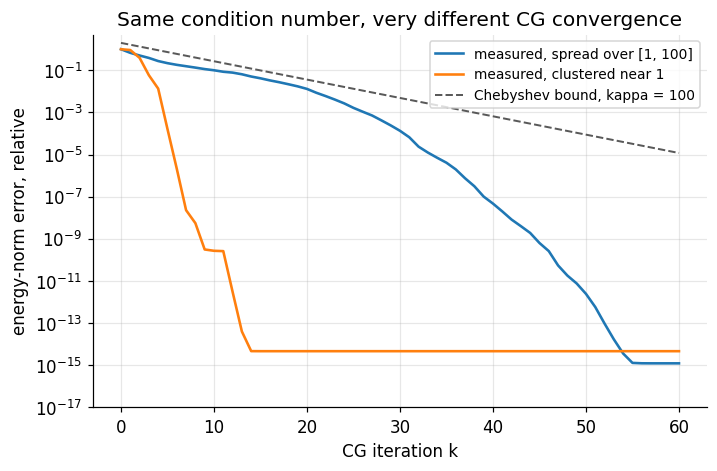

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
kk = np.arange(m2 + 1)
gam = (np.sqrt(100.0) - 1) / (np.sqrt(100.0) + 1)
for label, curve in curves.items():
    ax.semilogy(kk, np.maximum(curve, 1e-17), lw=1.7, label=f"measured, {label}")
ax.semilogy(kk, 2 * gam ** kk, "--", lw=1.3, color="0.35",
            label="Chebyshev bound, kappa = 100")
ax.set_ylim(1e-17, 5.0)
ax.set_xlabel("CG iteration k")
ax.set_ylabel("energy-norm error, relative")
ax.set_title("Same condition number, very different CG convergence")
ax.legend(fontsize=9)
plt.show()

Both solid curves stay below the dashed bound, as Theorem 4.7 requires. The clustered run falls
off a cliff after three steps — the three outliers are annihilated first, then the remaining
spectrum is an interval of width $0.05$ on which one more polynomial factor suffices.

That cliff is Theorem 4.6 statement 5 in practice: CG terminates once the polynomial can cover
the *distinct* parts of the spectrum, and a tight cluster counts as almost one point.

### 7.3 The minimax polynomial that CG is really using

Lemma 5.6.1 claims $p_k^{\star}(\lambda) = T_k(\ell(\lambda))/T_k(w)$ is the smallest possible on
$[a,b]$ among degree-$k$ polynomials with $p(0)=1$, and that it equioscillates between
$\pm 1/T_k(w)$ at $k+1$ points.

The cell draws $p_6^{\star}$ on $[1, 20]$, marks the seven equioscillation points, and overlays the
natural competitor $q(\lambda) = (1 - 2\lambda/(a+b))^{6}$ — the polynomial that optimally damps
the *midpoint* of the spectrum, which is what a fixed-step Richardson iteration uses.

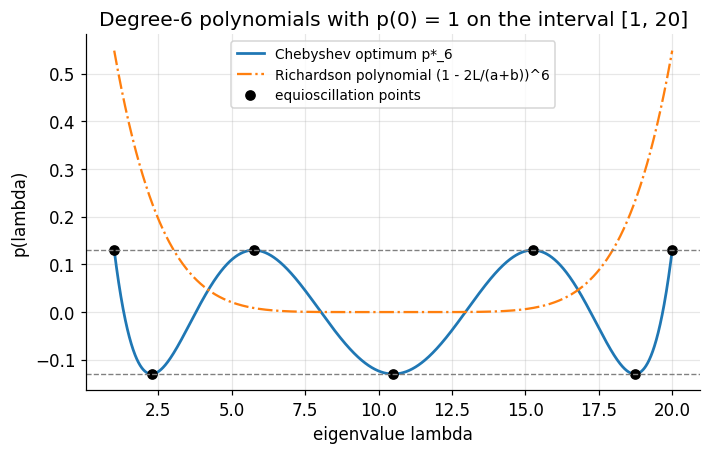

interval [a, b] = [1.0, 20.0],  kappa = 20.0,  degree k = 6
T_k(w) at w = 1.105263 is 7.694432
max |p*_6|  on [a,b] = 0.129964   1/T_k(w) = 0.129964
max |q_6|   on [a,b] = 0.548537
Chebyshev bound 2((sqrt k - 1)/(sqrt k + 1))^6 = 0.130518
equioscillation values: [ 0.13 -0.13  0.13 -0.13  0.13 -0.13  0.13]


In [8]:
from numpy.polynomial import chebyshev as npcheb

a_lo, b_hi, k_deg = 1.0, 20.0, 6
w_pt = (b_hi + a_lo) / (b_hi - a_lo)
T_at_w = npcheb.chebval(w_pt, [0] * k_deg + [1])
lam_grid = np.linspace(a_lo, b_hi, 2000)
ell = (b_hi + a_lo - 2 * lam_grid) / (b_hi - a_lo)
p_star = npcheb.chebval(ell, [0] * k_deg + [1]) / T_at_w
q_naive = (1 - 2 * lam_grid / (a_lo + b_hi)) ** k_deg

theta = np.arange(k_deg + 1) * np.pi / k_deg
lam_ext = (b_hi + a_lo - np.cos(theta) * (b_hi - a_lo)) / 2
p_ext = npcheb.chebval((b_hi + a_lo - 2 * lam_ext) / (b_hi - a_lo),
                       [0] * k_deg + [1]) / T_at_w

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(lam_grid, p_star, lw=1.8, label="Chebyshev optimum p*_6")
ax.plot(lam_grid, q_naive, lw=1.5, ls="-.", label="Richardson polynomial (1 - 2L/(a+b))^6")
ax.plot(lam_ext, p_ext, "o", ms=6, color="k", label="equioscillation points")
for s in (+1, -1):
    ax.axhline(s / T_at_w, lw=0.9, ls="--", color="0.5")
ax.set_xlabel("eigenvalue lambda")
ax.set_ylabel("p(lambda)")
ax.set_title("Degree-6 polynomials with p(0) = 1 on the interval [1, 20]")
ax.legend(fontsize=9)
plt.show()

print(f"interval [a, b] = [{a_lo}, {b_hi}],  kappa = {b_hi/a_lo:.1f},  degree k = {k_deg}")
print(f"T_k(w) at w = {w_pt:.6f} is {T_at_w:.6f}")
print(f"max |p*_6|  on [a,b] = {np.abs(p_star).max():.6f}   1/T_k(w) = {1/T_at_w:.6f}")
print(f"max |q_6|   on [a,b] = {np.abs(q_naive).max():.6f}")
print(f"Chebyshev bound 2((sqrt k - 1)/(sqrt k + 1))^6 = "
      f"{2*((np.sqrt(b_hi/a_lo)-1)/(np.sqrt(b_hi/a_lo)+1))**6:.6f}")
print("equioscillation values:", np.round(p_ext, 8))
assert abs(np.abs(p_star).max() - 1 / T_at_w) < 1e-9
assert np.abs(q_naive).max() > np.abs(p_star).max()
assert np.allclose(np.abs(p_ext), 1 / T_at_w)

The seven black dots alternate exactly between $+0.129964$ and $-0.129964$, which is
$\pm 1/T_6(w)$ — the equioscillation that Lemma 5.6.1 turns into a proof of optimality.

The Richardson polynomial reaches $0.548537$ on the same interval, $4.2$ times larger. That
factor is the entire advantage of CG over a fixed-step method: both build a degree-$k$
polynomial, but only one of them builds the *right* one, and it does so without ever being told
$a$ or $b$.

The printed Chebyshev bound $0.130518$ exceeds the exact minimax value $0.129964$ by four parts
in a thousand, so Step 4 of Proof 5.6 — dropping the second term of $T_k$ — costs almost
nothing. All of the slack in Theorem 4.7 comes from Step 2, the relaxation of the spectrum to an
interval.

### 7.4 Removing the hypotheses

Three experiments, one per hypothesis claimed necessary in Section 4.

- **Theorem 4.3.** Diagonal dominance cannot be weakened to positive definiteness. The matrix
  $A = 0.1\,I + 0.9\,\mathbf{1}\mathbf{1}^{\top}$ is positive definite with spectrum
  $\{2.8, 0.1, 0.1\}$, yet $\rho(G_{\mathrm{J}}) = 1.8$.
- **Theorem 4.4.** $\omega$ outside $(0,2)$ must fail, and Kahan's bound is tight at
  $\omega = 1.9$.
- **Theorem 4.6.** CG needs positive definiteness, not merely symmetry. On
  $A = \operatorname{diag}(1,-1)$ with $b = (1,1)^{\top}$ the very first step divides by zero.

In [9]:
print("=== Theorem 4.3: positive definite is not enough for Jacobi ===")
A_pd = 0.1 * np.eye(3) + 0.9 * np.ones((3, 3))
print("  spectrum of A            :", np.linalg.eigvalsh(A_pd))
dom = [abs(A_pd[i, i]) - sum(abs(A_pd[i, j]) for j in range(3) if j != i) for i in range(3)]
print("  diagonal dominance margin:", np.round(dom, 4), " (negative: not dominant)")
D_pd = np.diag(np.diag(A_pd))
L_pd = -np.tril(A_pd, -1)
U_pd = -np.triu(A_pd, 1)
rj_pd = max(abs(np.linalg.eigvals(np.linalg.solve(D_pd, L_pd + U_pd))))
rg_pd = max(abs(np.linalg.eigvals(np.linalg.solve(D_pd - L_pd, U_pd))))
print(f"  rho(G_Jacobi) = {rj_pd:.6f}   rho(G_GaussSeidel) = {rg_pd:.6f}")
x_true = np.array([1.0, 2.0, 3.0])
b_pd = A_pd @ x_true
xj, xg = np.zeros(3), np.zeros(3)
for k in range(1, 61):
    xj = np.linalg.solve(D_pd, (L_pd + U_pd) @ xj + b_pd)
    xg = np.linalg.solve(D_pd - L_pd, U_pd @ xg + b_pd)
    if k in (1, 4, 20, 60):
        print(f"    k = {k:2d}:  Jacobi error {np.linalg.norm(xj-x_true):.4e}"
              f"    Gauss-Seidel error {np.linalg.norm(xg-x_true):.4e}")
assert rj_pd > 1.0 and rg_pd < 1.0

print("\n=== Theorem 4.4: Kahan's bound and omega outside (0, 2) ===")
print("  omega    rho(G_omega)   |1 - omega|")
for w in (0.5, 1.0, 8 - 4 * np.sqrt(3), 1.9, 2.1):
    Mw = D22 / w - L22
    Nw = (1 / w - 1) * D22 + U22
    rw = max(abs(np.linalg.eigvals(np.linalg.solve(Mw, Nw))))
    print(f"  {w:6.4f}   {rw:.6f}      {abs(1-w):.6f}   "
          f"{'converges' if rw < 1 else 'DIVERGES'}")
    assert rw >= abs(1 - w) - 1e-12
Mw = D22 / 2.1 - L22
Nw = (1 / 2.1 - 1) * D22 + U22
xw = np.zeros(2)
for k in range(1, 21):
    xw = np.linalg.solve(Mw, Nw @ xw + b22)
print(f"  omega = 2.1 after 20 steps: error = {np.linalg.norm(xw - 1):.4e}")

print("\n=== Theorem 4.6: CG needs positive definiteness ===")
A_ind = np.diag([1.0, -1.0])
b_ind = np.array([1.0, 1.0])
p0 = b_ind.copy()
print(f"  A = diag(1, -1) is symmetric but indefinite; p_0 = r_0 = {p0}")
print(f"  p_0^T A p_0 = {p0 @ A_ind @ p0:.1f}  -> alpha_0 = (r_0.r_0) / 0 is undefined")
assert p0 @ A_ind @ p0 == 0.0

Q_ind, _ = np.linalg.qr(rng.standard_normal((20, 20)))
spec_ind = np.concatenate([np.linspace(-1.0, -0.1, 10), np.linspace(0.1, 1.0, 10)])
A_ind2 = Q_ind @ np.diag(spec_ind) @ Q_ind.T
A_ind2 = (A_ind2 + A_ind2.T) / 2
b_ind2 = rng.standard_normal(20)
_, R_ind, P_ind = cg_history(A_ind2, b_ind2, 14)
res_ind = np.linalg.norm(R_ind, axis=1)
print("  a 20x20 symmetric indefinite matrix, eigenvalues in [-1,-0.1] U [0.1,1]")
print("  CG residual norms:", np.round(res_ind[:12], 3))
print(f"  largest residual {res_ind.max():.1f} at step {int(res_ind.argmax())}, "
      f"against ||b|| = {np.linalg.norm(b_ind2):.3f}")
print("  signs of p_k^T A p_k:", np.sign([P_ind[j] @ A_ind2 @ P_ind[j] for j in range(10)]))
assert res_ind.max() > 3 * res_ind[0]

=== Theorem 4.3: positive definite is not enough for Jacobi ===
  spectrum of A            : [0.1 0.1 2.8]
  diagonal dominance margin: [-0.8 -0.8 -0.8]  (negative: not dominant)
  rho(G_Jacobi) = 1.800000   rho(G_GaussSeidel) = 0.853815
    k =  1:  Jacobi error 6.3640e+00    Gauss-Seidel error 5.4872e+00
    k =  4:  Jacobi error 3.6377e+01    Gauss-Seidel error 3.3800e+00
    k = 20:  Jacobi error 4.4161e+05    Gauss-Seidel error 2.5669e-01
    k = 60:  Jacobi error 7.1770e+15    Gauss-Seidel error 4.7163e-04

=== Theorem 4.4: Kahan's bound and omega outside (0, 2) ===
  omega    rho(G_omega)   |1 - omega|
  0.5000   0.710768      0.500000   converges
  1.0000   0.250000      0.000000   converges
  1.0718   0.071797      0.071797   converges
  1.9000   0.900000      0.900000   converges
  2.1000   1.100000      1.100000   DIVERGES
  omega = 2.1 after 20 steps: error = 1.5079e+01

=== Theorem 4.6: CG needs positive definiteness ===
  A = diag(1, -1) is symmetric but indefinite; p_0 =

Positive definiteness does not rescue Jacobi: $\rho(G_{\mathrm{J}}) = 1.8$ and the error grows
from $3.7$ to $4.4 \times 10^{5}$ in $20$ steps and to $7.2 \times 10^{15}$ in $60$, while
Gauss-Seidel on the same matrix converges steadily. So the
hypothesis in Theorem 4.3 is doing real work, and the two methods are not interchangeable.

Kahan's bound $\rho(G_\omega) \ge \lvert 1-\omega \rvert$ is respected at every $\omega$ and
attained exactly at $\omega = 1.9$ and $\omega = 2.1$. At $\omega = 2.1$ the iteration diverges,
as Theorem 4.4 requires.

For CG the failure is not slow convergence but an undefined arithmetic operation:
$p_0^{\top}Ap_0$ is exactly zero. On the larger indefinite matrix the denominators change sign
from step to step and the residual jumps from $4.24$ to $23.4$ in one step and then oscillates
without settling — the energy
"norm" that CG minimizes is not a norm when $A$ is indefinite, so there is nothing to descend.
This is why symmetric indefinite systems are handed to MINRES instead (Problem L2.6).

### 7.5 Hand-rolled against the library

The cell solves an $80 \times 80$ system with $\kappa_2(A) = 10^3$ using the CG of Definition 3.8,
and a non-symmetric $80 \times 80$ system using the GMRES of Definition 3.9, and compares both
against `scipy.sparse.linalg`.

In [10]:
from scipy.sparse.linalg import cg as scipy_cg, gmres as scipy_gmres


def cg_solve(A, b, tol=1e-10, maxit=2000):
    """CG driven to a relative residual tolerance; returns the solution and iteration count."""
    x = np.zeros(len(b))
    r = b - A @ x
    p = r.copy()
    rr = r @ r
    nb = np.linalg.norm(b)
    it = 0
    while np.sqrt(rr) > tol * nb and it < maxit:
        Ap = A @ p
        alpha = rr / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rr_new = r @ r
        p = r + (rr_new / rr) * p
        rr = rr_new
        it += 1
    return x, it


def gmres_solve(A, b, steps):
    """Full GMRES; returns the iterate after `steps` steps and the residual history."""
    n_ = len(b)
    Qa = np.zeros((n_, steps + 1))
    H = np.zeros((steps + 1, steps))
    beta = np.linalg.norm(b)
    Qa[:, 0] = b / beta
    res, y = [beta], np.zeros(1)
    for k in range(steps):
        v = A @ Qa[:, k]
        for i in range(k + 1):
            H[i, k] = Qa[:, i] @ v
            v = v - H[i, k] * Qa[:, i]
        H[k + 1, k] = np.linalg.norm(v)
        if H[k + 1, k] > 1e-14:
            Qa[:, k + 1] = v / H[k + 1, k]
        rhs = np.zeros(k + 2)
        rhs[0] = beta
        y, *_ = np.linalg.lstsq(H[:k + 2, :k + 1], rhs, rcond=None)
        res.append(np.linalg.norm(rhs - H[:k + 2, :k + 1] @ y))
    return Qa[:, :steps] @ y, np.array(res)


m3 = 80
Q3, _ = np.linalg.qr(rng.standard_normal((m3, m3)))
A_big = Q3 @ np.diag(np.logspace(0, 3, m3)) @ Q3.T
A_big = (A_big + A_big.T) / 2
b_big = rng.standard_normal(m3)
x_dense = np.linalg.solve(A_big, b_big)
x_hand, iters = cg_solve(A_big, b_big)
x_scipy, info = scipy_cg(A_big, b_big, rtol=1e-10, atol=0.0, maxiter=2000)
print("conjugate gradient, kappa = 1e3")
print(f"  hand-rolled iterations              : {iters}")
print(f"  ||x_hand - x_scipy|| / ||x||        : "
      f"{np.linalg.norm(x_hand - x_scipy)/np.linalg.norm(x_dense):.3e}")
print(f"  ||x_hand - x_direct|| / ||x||       : "
      f"{np.linalg.norm(x_hand - x_dense)/np.linalg.norm(x_dense):.3e}")
assert np.linalg.norm(x_hand - x_dense) / np.linalg.norm(x_dense) < 1e-8

A_ns = rng.standard_normal((m3, m3)) / np.sqrt(m3) + 2.0 * np.eye(m3)
b_ns = rng.standard_normal(m3)
x_ns = np.linalg.solve(A_ns, b_ns)
x_gh, res_gh = gmres_solve(A_ns, b_ns, 40)
x_gs, info2 = scipy_gmres(A_ns, b_ns, rtol=1e-12, atol=0.0, restart=40, maxiter=200)
print("\nGMRES on a non-symmetric matrix")
print(f"  ||x_hand - x_direct|| / ||x||       : "
      f"{np.linalg.norm(x_gh - x_ns)/np.linalg.norm(x_ns):.3e}")
print(f"  ||x_scipy - x_direct|| / ||x||      : "
      f"{np.linalg.norm(x_gs - x_ns)/np.linalg.norm(x_ns):.3e}")
print(f"  relative residual after 10, 20, 40 steps: "
      f"{res_gh[10]/res_gh[0]:.3e}, {res_gh[20]/res_gh[0]:.3e}, {res_gh[40]/res_gh[0]:.3e}")
print(f"  residual history non-increasing     : "
      f"{bool(np.all(np.diff(res_gh) <= 1e-12))}")
assert np.linalg.norm(x_gh - x_ns) / np.linalg.norm(x_ns) < 1e-10
assert np.all(np.diff(res_gh) <= 1e-12)

conjugate gradient, kappa = 1e3
  hand-rolled iterations              : 167
  ||x_hand - x_scipy|| / ||x||        : 0.000e+00
  ||x_hand - x_direct|| / ||x||       : 5.260e-11



GMRES on a non-symmetric matrix
  ||x_hand - x_direct|| / ||x||       : 1.414e-15
  ||x_scipy - x_direct|| / ||x||      : 1.066e-12
  relative residual after 10, 20, 40 steps: 4.161e-04, 1.402e-07, 1.412e-15
  residual history non-increasing     : True


The hand-written CG agrees with `scipy.sparse.linalg.cg` to the last bit — the difference is
exactly zero, because the two implementations perform the same operations in the same order —
and both land within $5 \times 10^{-11}$ of the direct solve.

The hand-written GMRES reaches $1.4 \times 10^{-15}$ relative error, and its residual history is
verified non-increasing step by step, which is Theorem 4.8 part 3 as a runtime assertion rather
than a claim.

### 7.6 The two ways GMRES fails

Theorem 4.8 part 4 has two factors, and each can be the culprit on its own.

- The $8 \times 8$ cyclic shift is **orthogonal**, so $\kappa_2(V) = 1$ and the bound is as good
  as a bound can be; its eigenvalues are the eighth roots of unity, encircling the origin, and
  the minimax factor is $1$ until $k = 8$.
- The matrix $J = I + 10 N$, with $N$ the nilpotent shift, has $\operatorname{spec}(J) = \{1\}$,
  so the minimax factor is $0$ from $k = 1$ onwards; but $J$ is defective, $\kappa_2(V)$ is
  numerically infinite, and the bound is vacuous.

cyclic shift S
  ||S^T S - S S^T||_F  = 0.0e+00   (exactly normal)
  |eigenvalues|        = [1. 1. 1. 1. 1. 1. 1. 1.]
  relative residuals   = [1. 1. 1. 1. 1. 1. 1. 1. 0.]

defective J = I + 10 N
  ||J^T J - J J^T||_F  = 141.4
  eigenvalues          = [1.]   (all equal to 1)
  cond_2(V)            = 1.503e+117
  relative residuals   = [1.     0.3212 0.3198 0.3198 0.3198 0.3198 0.3198 0.3198 0.    ]


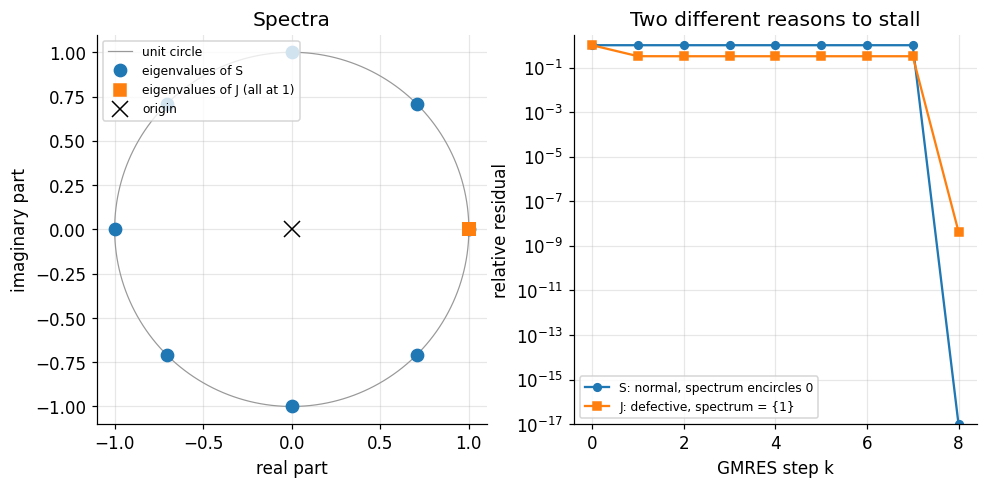

In [11]:
n_g = 8
S = np.zeros((n_g, n_g))
for i in range(n_g):
    S[(i + 1) % n_g, i] = 1.0
b_S = np.zeros(n_g)
b_S[0] = 1.0

J = np.eye(n_g) + 10.0 * np.diag(np.ones(n_g - 1), 1)
b_J = np.ones(n_g) / np.sqrt(n_g)

_, res_S = gmres_solve(S, b_S, n_g)
_, res_J = gmres_solve(J, b_J, n_g)
ev_S = np.linalg.eigvals(S)
ev_J = np.linalg.eigvals(J)
_, V_J = np.linalg.eig(J)

print("cyclic shift S")
print(f"  ||S^T S - S S^T||_F  = {np.linalg.norm(S.T @ S - S @ S.T):.1e}   (exactly normal)")
print(f"  |eigenvalues|        = {np.round(np.abs(ev_S), 12)}")
print(f"  relative residuals   = {np.round(res_S / res_S[0], 12)}")
print("\ndefective J = I + 10 N")
print(f"  ||J^T J - J J^T||_F  = {np.linalg.norm(J.T @ J - J @ J.T):.1f}")
print(f"  eigenvalues          = {np.unique(np.round(ev_J.real, 10))}   (all equal to 1)")
print(f"  cond_2(V)            = {np.linalg.cond(V_J):.3e}")
print(f"  relative residuals   = {np.round(res_J / res_J[0], 6)}")
assert np.linalg.norm(S.T @ S - S @ S.T) == 0.0
assert np.allclose(res_S[:n_g] / res_S[0], 1.0)
assert res_J[n_g - 1] / res_J[0] > 0.3

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.4, 4.6))
circle = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
axL.plot(circle.real, circle.imag, lw=0.8, color="0.6", label="unit circle")
axL.plot(ev_S.real, ev_S.imag, "o", ms=8, label="eigenvalues of S")
axL.plot(ev_J.real, ev_J.imag, "s", ms=8, label="eigenvalues of J (all at 1)")
axL.plot([0], [0], "kx", ms=10, label="origin")
axL.set_aspect("equal")
axL.set_xlabel("real part")
axL.set_ylabel("imaginary part")
axL.set_title("Spectra")
axL.legend(fontsize=8, loc="upper left")

steps_axis = np.arange(n_g + 1)
axR.semilogy(steps_axis, np.maximum(res_S / res_S[0], 1e-17), "o-", ms=5,
             label="S: normal, spectrum encircles 0")
axR.semilogy(steps_axis, np.maximum(res_J / res_J[0], 1e-17), "s-", ms=5,
             label="J: defective, spectrum = {1}")
axR.set_ylim(1e-17, 3.0)
axR.set_xlabel("GMRES step k")
axR.set_ylabel("relative residual")
axR.set_title("Two different reasons to stall")
axR.legend(fontsize=8, loc="lower left")
plt.show()

The left panel shows why the two failures are genuinely different. For $S$ the eigenvalues are
spread around the unit circle and surround the origin; no low-degree polynomial can be $1$ at
the origin and small on all of them. For $J$ every eigenvalue sits at $1$, as far from a
difficult configuration as possible.

The right panel shows both stalling anyway. The lesson is Theorem 4.8 read honestly: GMRES
convergence is bounded by a *product* of a spectral factor and an eigenvector-conditioning
factor, and either factor alone can make the bound useless. A clustered spectrum is not
sufficient for fast convergence, and non-normality is not necessary for stagnation.

## 8. Applications

Four settings in which the results above are the working tool, not an illustration.

### 8.1 Discretized elliptic partial differential equations

Discretizing $-\Delta u = f$ on a square with an $N \times N$ grid gives a symmetric positive
definite system of size $n = N^2$ whose eigenvalues are
$\lambda_{ij} = 4 - 2\cos\frac{i\pi}{N+1} - 2\cos\frac{j\pi}{N+1}$.

Hence $\kappa_2 \sim 4/(\pi^2 h^2)$ with $h = 1/(N+1)$, so $\sqrt{\kappa_2}$ grows like $N$, and
Theorem 4.7 predicts that the CG iteration count grows like $N = \sqrt{n}$, not like $n$.

That is the whole reason finite-element and finite-difference codes are built on preconditioned
CG: the cost is $O(n^{3/2})$ against $O(n^3)$ for a dense factorization, and $O(n)$ once
multigrid supplies the preconditioner (Theorem 4.10).

### 8.2 Gradient descent is a stationary iteration

Minimizing $f(x) = \tfrac12 x^{\top}Ax - b^{\top}x$ with $A$ symmetric positive definite has
gradient $\nabla f(x) = Ax - b = -r(x)$, so gradient descent with step $\eta$ reads

$$
x_{k+1} = x_k - \eta \nabla f(x_k) = (I - \eta A)x_k + \eta b .
$$

This is exactly Definition 3.4 with $M = \eta^{-1} I$: **gradient descent on a quadratic is
Richardson iteration**. Theorem 4.2 then gives its rate as
$\rho(I - \eta A) = \max_i \lvert 1 - \eta\lambda_i \rvert$, minimized at
$\eta^{\star} = 2/(\lambda_{\min}+\lambda_{\max})$ with value $(\kappa-1)/(\kappa+1)$.

Comparing with Theorem 4.7: gradient descent pays $\kappa$, CG pays $\sqrt{\kappa}$. Momentum
methods recover part of the gap; CG is what the gap looks like when it is closed exactly.

### 8.3 Hessian-free optimization and Newton-CG

A Newton step solves $\nabla^2 f(\theta)\,\Delta\theta = -\nabla f(\theta)$. In a network with
$10^8$ parameters the Hessian cannot be formed, let alone factored.

But CG never needs the matrix — only the product $\nabla^2 f(\theta) v$, which reverse-mode
differentiation supplies at roughly the cost of one gradient:

$$
\nabla^2 f(\theta)\, v = \left. \frac{d}{ds} \nabla f(\theta + sv) \right|_{s=0} .
$$

Truncating CG after a few dozen steps gives an inexact Newton direction, which is the
Newton-CG family (Nocedal and Wright, *Numerical Optimization*, 2nd ed., section 7.1). Because
CG is monotone in the energy norm by Theorem 4.6 statement 4, stopping early still returns a
descent direction.

### 8.4 Preconditioning in machine learning and in physics

Adaptive optimizers are diagonal preconditioners. Adam and RMSProp rescale each coordinate by an
estimate of its curvature, which is exactly $M = \operatorname{diag}(A)$ in Definition 3.10; K-FAC
uses a Kronecker-factored $M \approx A \otimes B$ so that $M^{-1}v$ costs two small solves
instead of one huge one (Problem L2.9).

In physics and engineering codes the same machinery appears as incomplete Cholesky for structural
stiffness matrices, as algebraic multigrid for reservoir simulation, and as BiCGSTAB or GMRES
with an ILU preconditioner for the pressure-Poisson step of an incompressible Navier-Stokes
solver.

The cell below runs the three quantitative claims of this section: the $\sqrt{n}$ growth of the
CG iteration count on the 2-D Poisson problem, the effect of a Jacobi preconditioner on a badly
scaled system, and the $\kappa$-versus-$\sqrt{\kappa}$ gap between gradient descent and CG.

In [12]:
def poisson_2d(N):
    """The 5-point Laplacian on an N-by-N interior grid, size n = N^2."""
    I = np.eye(N)
    return np.kron(I, laplacian_1d(N)) + np.kron(laplacian_1d(N), I)


def pcg_solve(A, b, apply_Minv=None, tol=1e-8, maxit=5000):
    """Preconditioned CG; apply_Minv(r) returns M^{-1} r. Returns iterate and count."""
    x = np.zeros(len(b))
    r = b - A @ x
    z = r.copy() if apply_Minv is None else apply_Minv(r)
    p = z.copy()
    rz = r @ z
    nb = np.linalg.norm(b)
    it = 0
    while np.linalg.norm(r) > tol * nb and it < maxit:
        Ap = A @ p
        alpha = rz / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        z = r.copy() if apply_Minv is None else apply_Minv(r)
        rz_new = r @ z
        p = z + (rz_new / rz) * p
        rz = rz_new
        it += 1
    return x, it


print("8.1  2-D Poisson: CG iteration count against the grid")
print("   N     n    kappa_2     sqrt(kappa)   CG iters   iters/sqrt(kappa)")
for N in (8, 12, 16, 24, 32):
    Ap2 = poisson_2d(N)
    lam2 = np.linalg.eigvalsh(Ap2)
    kap2 = lam2[-1] / lam2[0]
    bp2 = rng.standard_normal(N * N)
    _, it2 = pcg_solve(Ap2, bp2)
    print(f"  {N:3d} {N*N:5d}  {kap2:9.2f}   {np.sqrt(kap2):9.3f}   {it2:6d}        {it2/np.sqrt(kap2):.3f}")

print("\n8.4  Jacobi preconditioning of a badly scaled Poisson system")
N = 16
L2d = poisson_2d(N)
scale = np.exp(rng.uniform(-4.0, 4.0, N * N))
A_bad = np.diag(np.sqrt(scale)) @ L2d @ np.diag(np.sqrt(scale))
A_bad = (A_bad + A_bad.T) / 2
b_bad = rng.standard_normal(N * N)
diag_bad = np.diag(A_bad)
_, it_plain = pcg_solve(A_bad, b_bad)
_, it_prec = pcg_solve(A_bad, b_bad, apply_Minv=lambda r: r / diag_bad)
kap_plain = np.linalg.cond(A_bad)
Dm = np.diag(1.0 / np.sqrt(diag_bad))
kap_prec = np.linalg.cond(Dm @ A_bad @ Dm)
print(f"  kappa_2(A)        = {kap_plain:12.2f}   CG iterations   = {it_plain}")
print(f"  kappa_2(M^-1 A)   = {kap_prec:12.2f}   PCG iterations  = {it_prec}")
print(f"  ratio of sqrt(kappa) = {np.sqrt(kap_plain/kap_prec):.2f}   "
      f"ratio of iterations = {it_plain/it_prec:.2f}")
assert kap_prec < kap_plain / 100 and it_prec < it_plain / 5

print("\n8.2  gradient descent against CG on the same system, kappa = 1e4")
m4 = 200
Q4, _ = np.linalg.qr(rng.standard_normal((m4, m4)))
spec4 = np.logspace(0, 4, m4)
A4 = Q4 @ np.diag(spec4) @ Q4.T
A4 = (A4 + A4.T) / 2
b4 = rng.standard_normal(m4)
x4 = np.linalg.solve(A4, b4)
eta = 2.0 / (spec4[0] + spec4[-1])
kap4 = spec4[-1] / spec4[0]
xg4 = np.zeros(m4)
hist = [np.linalg.norm(xg4 - x4)]
for _ in range(2000):
    xg4 = xg4 + eta * (b4 - A4 @ xg4)
    hist.append(np.linalg.norm(xg4 - x4))
hist = np.array(hist) / hist[0]
_, it_cg4 = pcg_solve(A4, b4, tol=1e-8)
print(f"  optimal step eta*         = {eta:.6e}")
print(f"  predicted GD rate (k-1)/(k+1) = {(kap4-1)/(kap4+1):.6f}")
print(f"  observed  GD rate             = {(hist[2000]/hist[1000])**(1/1000):.6f}")
print(f"  CG rate (sqrt k - 1)/(sqrt k + 1) = {(np.sqrt(kap4)-1)/(np.sqrt(kap4)+1):.6f}")
print(f"  GD relative error after 2000 steps: {hist[-1]:.3e}")
print(f"  CG iterations to relative residual 1e-8: {it_cg4}")
assert it_cg4 < 1000

8.1  2-D Poisson: CG iteration count against the grid
   N     n    kappa_2     sqrt(kappa)   CG iters   iters/sqrt(kappa)
    8    64      32.16       5.671       26        4.585
   12   144      67.83       8.236       39        4.735


   16   256     116.46      10.792       50        4.633


   24   576     252.64      15.895       77        4.844


   32  1024     440.69      20.993      100        4.764

8.4  Jacobi preconditioning of a badly scaled Poisson system
  kappa_2(A)        =     27447.98   CG iterations   = 670
  kappa_2(M^-1 A)   =       116.46   PCG iterations  = 54
  ratio of sqrt(kappa) = 15.35   ratio of iterations = 12.41

8.2  gradient descent against CG on the same system, kappa = 1e4
  optimal step eta*         = 1.999800e-04
  predicted GD rate (k-1)/(k+1) = 0.999800
  observed  GD rate             = 0.999711
  CG rate (sqrt k - 1)/(sqrt k + 1) = 0.980198
  GD relative error after 2000 steps: 5.355e-01
  CG iterations to relative residual 1e-8: 569


On the 2-D Poisson problem the ratio (iterations)$/\sqrt{\kappa_2}$ stays between $4.59$ and
$4.84$ across a sixteen-fold increase in $n$: the iteration count is proportional to
$\sqrt{\kappa_2}$, exactly as Theorem 4.7 says, and therefore to $\sqrt{n}$.

The badly scaled system has $\kappa_2 = 2.74 \times 10^{4}$ and needs $670$ CG iterations. A
Jacobi preconditioner — one division per entry — brings $\kappa_2(M^{-1}A)$ down to $116.5$ and
the count to $54$. Theorem 4.9 predicted a $15.4$-fold speed-up from the square roots; the
measured factor is $12.4$.

The last block is the $\kappa$-against-$\sqrt{\kappa}$ gap in numbers. At $\kappa = 10^4$,
optimally stepped gradient descent contracts at $0.99971$ per step, close to the predicted
$0.99980$, and after $2000$ iterations has removed only $46$ percent of the error. CG reaches a
relative residual of $10^{-8}$ in $569$ iterations.

## 9. Key Takeaways

- **Conditioning bounds what any solver can deliver.** The relative error is at most
  $\kappa(A)$ times the relative data perturbation, and that bound is attained (Theorem 4.1). A
  backward stable algorithm on an ill-conditioned problem still returns a large error, and this
  is the problem's fault.

- **A stationary iteration converges exactly when $\rho(G) \lt 1$**, where $G = M^{-1}N$
  (Theorem 4.2). The criterion is asymptotic: Example 6.5 has $\rho = 0.9$ and
  $\lVert G^k \rVert$ peaking at $19.4$ before it decays.

- **Strict diagonal dominance is sufficient for Jacobi and Gauss-Seidel, and positive
  definiteness is not** (Theorem 4.3). Section 7.4 runs a positive definite matrix with
  $\rho(G_{\mathrm{J}}) = 1.8$.

- **SOR needs $0 \lt \omega \lt 2$** because $\rho(G_\omega) \ge \lvert 1 - \omega \rvert$
  (Theorem 4.4), and for symmetric positive definite $A$ that range is also sufficient
  (Theorem 4.5, cited).

- **The conjugate gradient method builds an $A$-orthogonal basis with a three-term recurrence**,
  its residuals are mutually orthogonal, and it terminates in at most $n$ steps — in fact in at
  most $d$ steps for $d$ distinct eigenvalues (Theorem 4.6). Section 7.1 measures both
  orthogonality defects below one machine epsilon.

- **CG contracts at $(\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$ in the energy norm** (Theorem 4.7),
  a square root that gradient descent does not get. The proof is the Chebyshev minimax lemma
  (Lemma 5.6.1), and the bound sees only $[\lambda_{\min},\lambda_{\max}]$: two spectra with the
  same $\kappa = 100$ took $47$ and $12$ steps in Section 7.2.

- **GMRES minimizes the residual over the Krylov space and is monotone** (Theorem 4.8), but its
  convergence is governed by a product of a spectral factor and $\kappa_2(V)$. Section 7.6
  stalls it twice, once with a perfectly normal matrix and once with a defective one whose entire
  spectrum is a single point.

- **Preconditioning replaces $\kappa_2(A)$ by $\kappa_2(M^{-1}A)$** and nothing else changes
  (Theorem 4.9). In Section 8 one diagonal scaling cut $\kappa_2$ from $2.74 \times 10^4$ to
  $116.5$ and the iteration count from $670$ to $54$.

## 10. References

**Textbooks.**

- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra*, SIAM 1997 — Lecture 12
  (conditioning), Lectures 14 and 15 (stability, backward error), Lecture 33 (Arnoldi),
  Lecture 35 (GMRES), Lecture 38 (conjugate gradients, with the Chebyshev bound as Theorem 38.5).
- Saad, Y. *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 — chapter 4
  (Jacobi, Gauss-Seidel, SOR and their convergence theory, Theorems 4.1 to 4.9), chapter 6
  (Krylov subspace methods, Arnoldi, GMRES, Theorem 6.11), chapter 10 (preconditioning).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed., Johns Hopkins 2013 —
  section 11.2 (classical iterations), section 11.3 (conjugate gradients, Theorem 11.3.3),
  section 11.5 (preconditioning).
- Higham, N. J. *Accuracy and Stability of Numerical Algorithms*, 2nd ed., SIAM 2002 —
  section 3.1 (the $\gamma_n$ notation), Theorem 8.5 (componentwise backward error of
  substitution), chapter 7 (perturbation theory for linear systems).
- Nocedal, J. and Wright, S. J. *Numerical Optimization*, 2nd ed., Springer 2006 — chapter 5
  (conjugate gradient, Theorems 5.1 to 5.5), section 7.1 (Newton-CG and Hessian-free steps).
- Young, D. M. *Iterative Solution of Large Linear Systems*, Academic Press 1971 —
  Theorem 3.4.1 (Kahan), Theorem 4.3.6 (Ostrowski-Reich), chapter 6 (optimal SOR for
  consistently ordered matrices).
- Varga, R. S. *Matrix Iterative Analysis*, 2nd ed., Springer 2000 — Theorem 3.11
  (Ostrowski-Reich), chapter 4 (Stein-Rosenberg and successive overrelaxation).
- Hackbusch, W. *Multi-Grid Methods and Applications*, Springer 1985 — Theorems 6.1.7, 7.1.2
  and 7.2.2 (smoothing property, approximation property, mesh-independent convergence).
- Briggs, W. L., Henson, V. E. and McCormick, S. F. *A Multigrid Tutorial*, 2nd ed., SIAM 2000 —
  chapters 2 to 4.

**Papers.**

- Hestenes, M. R. and Stiefel, E. "Methods of conjugate gradients for solving linear systems",
  *Journal of Research of the National Bureau of Standards* **49**(6) (1952), 409-436.
- Saad, Y. and Schultz, M. H. "GMRES: a generalized minimal residual algorithm for solving
  nonsymmetric linear systems", *SIAM Journal on Scientific and Statistical Computing* **7**(3)
  (1986), 856-869.
- Paige, C. C. "Error analysis of the Lanczos algorithm for tridiagonalizing a symmetric matrix",
  *IMA Journal of Applied Mathematics* **18**(3) (1976), 341-349 — the loss of orthogonality
  noted in Section 7.1.
- Greenbaum, A., Ptak, V. and Strakos, Z. "Any nonincreasing convergence curve is possible for
  GMRES", *SIAM Journal on Matrix Analysis and Applications* **17**(3) (1996), 465-469 — the
  precise sense in which eigenvalues do not determine GMRES convergence.
- Elman, H. C. "Iterative methods for large sparse nonsymmetric systems of linear equations",
  PhD thesis, Yale University 1982 — the field-of-values bound of Problem L3.4.
- Strohmer, T. and Vershynin, R. "A randomized Kaczmarz algorithm with exponential convergence",
  *Journal of Fourier Analysis and Applications* **15**(2) (2009), 262-278.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Schur triangularization and the spectral theorem, used in Proofs 5.2 and 5.6:
  [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).
- Direct factorizations, the $O(n^3)$ baseline of Section 1:
  [Module 03](../03_linear_systems_and_direct_factorizations/).
- Conditioning and floating point in full:
  [numerical_computing/03](../../numerical_computing/03_conditioning_and_condition_numbers/).
- Practice problems for this module: [`exercises.ipynb`](exercises.ipynb).